<div style="background:linear-gradient(135deg,#07090f 0%,#0d1528 100%);padding:36px 44px;border-radius:14px;border-left:6px solid #c084fc;font-family:'Courier New',monospace;margin-bottom:8px">
<h1 style="color:#c084fc;margin:0 0 8px;font-size:2.2em;letter-spacing:2px">⚡ FCAS BIDDING BOT</h1>
<h3 style="color:#8b9dc3;margin:0 0 4px;font-weight:normal">ML-Optimized Frequency Control Ancillary Services — All 10 NEM Markets incl. Very Fast (1-sec)</h3>
<hr style="border:none;border-top:1px solid #263050;margin:18px 0">
<table style="color:#e0e0e0;font-size:0.9em;border-collapse:collapse">
<tr><td style="padding:4px 20px 4px 0;color:#c084fc"><b>Framework</b></td><td>Master ML/DL — 12 Steps across 5 Phases</td></tr>
<tr><td style="padding:4px 20px 4px 0;color:#c084fc"><b>Data</b></td><td>AEMO NEM via NEMOSIS — 10 FCAS markets (R1S, R6S, R60S, R5M, RREG + L1S, L6S, L60S, L5M, LREG)</td></tr>
<tr><td style="padding:4px 20px 4px 0;color:#c084fc"><b>Model</b></td><td>XGBoost + LightGBM ensemble → FCAS price forecast → LP bid optimisation</td></tr>
<tr><td style="padding:4px 20px 4px 0;color:#c084fc"><b>Output</b></td><td>AEMO-format 10 price-quantity bid bands (BP1–BP10) per service per interval</td></tr>
</table>
</div>

---
## 🎛️ Interactive Configuration — Edit This Cell

In [27]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║            USER CONFIGURATION — EDIT HERE                       ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Target Scope ─────────────────────────────────────────────────────
TARGET_YEAR      = 2025          # ← forecast year
TARGET_MONTH     = 1             # ← forecast month (1-12)
TARGET_WEEK      = None          # ← None=full month, or 1-5 for specific week
HISTORY_YEARS    = 2             # ← years of training history

# ── NEM Region ───────────────────────────────────────────────────────
NEM_REGION       = 'SA1'         # SA1 | VIC1 | NSW1 | QLD1 | TAS1

# ── BESS Asset Parameters ────────────────────────────────────────────
BESS_POWER_MW    = 100.0         # MW — rated power
BESS_CAPACITY_MWH= 200.0        # MWh — nameplate energy
BESS_ETA_CHARGE  = 0.95          # one-way charging efficiency
BESS_ETA_DISCHARGE=0.95          # one-way discharging efficiency
BESS_SOC_MIN     = 0.10          # minimum SoC (10%)
BESS_SOC_MAX     = 0.90          # maximum SoC (90%)
BESS_SOC_INIT    = 0.50          # starting SoC
BESS_CAPEX_KWH   = 220.0        # $/kWh installed cost
BESS_CYCLES_LIFE = 4000          # lifetime cycle count

# ── FCAS 10 Service Selection (since Oct 2023 — incl. Very Fast) ─────
FCAS_SERVICES = {
    # ── RAISE (inject power when frequency drops below 50 Hz) ──────
    'RAISE1SEC':  True,   # R1S  — Very Fast raise (1 second) — NEW Oct 2023
    'RAISE6SEC':  True,   # R6S  — Fast raise (6 seconds)
    'RAISE60SEC': True,   # R60S — Slow raise (60 seconds)
    'RAISE5MIN':  True,   # R5M  — Delayed raise (5 minutes)
    'RAISEREG':   True,   # RREG — Regulation raise (continuous)
    # ── LOWER (absorb power when frequency rises above 50 Hz) ─────
    'LOWER1SEC':  True,   # L1S  — Very Fast lower (1 second) — NEW Oct 2023
    'LOWER6SEC':  True,   # L6S  — Fast lower (6 seconds)
    'LOWER60SEC': True,   # L60S — Slow lower (60 seconds)
    'LOWER5MIN':  True,   # L5M  — Delayed lower (5 minutes)
    'LOWERREG':   True,   # LREG — Regulation lower (continuous)
}

# ── Model Options ────────────────────────────────────────────────────
MODEL_OPTIONS  = ['XGBoost', 'LightGBM', 'Ensemble']
RUN_HPO        = False    # True = Optuna HPO (~15 min extra)
N_TRIALS       = 60       # HPO trials if RUN_HPO=True

# ── Output / Plot ────────────────────────────────────────────────────
PLOT_DAY       = None     # 'YYYY-MM-DD' or None = auto-select best day
PLOT_WEEK      = 1        # Which week to plot in detail (1-5)

# ── Data Source ──────────────────────────────────────────────────────
DATA_SOURCE    = 'NEMOSIS'  # 'NEMOSIS' = real AEMO data | 'SYNTHETIC' = simulated

# ── Bid Band Configuration ───────────────────────────────────────────
N_BID_BANDS    = 10       # AEMO requires exactly 10 price-quantity bands (BP1–BP10)
BID_PRICE_FLOOR= 0.0     # $/MWh — FCAS bid floor
BID_PRICE_CAP  = 16600.0 # $/MWh — FCAS bid price cap (MPC)

print(f"  ╔══════════════════════════════════════════════════════════╗")
print(f"  ║  FCAS BIDDING BOT v2 — Configuration                    ║")
print(f"  ╠══════════════════════════════════════════════════════════╣")
print(f"  ║  Target:    {TARGET_YEAR}-{TARGET_MONTH:02d}  |  Region: {NEM_REGION:<5}            ║")
print(f"  ║  History:   {HISTORY_YEARS} years  |  BESS: {BESS_POWER_MW:.0f}MW/{BESS_CAPACITY_MWH:.0f}MWh       ║")
print(f"  ║  Services:  {sum(FCAS_SERVICES.values())}/10 FCAS markets enabled        ║")
print(f"  ║  Bid bands: {N_BID_BANDS} (BP1–BP10, AEMO format)             ║")
print(f"  ║  Models:    {', '.join(MODEL_OPTIONS):<30}       ║")
print(f"  ╚══════════════════════════════════════════════════════════╝")

  ╔══════════════════════════════════════════════════════════╗
  ║  FCAS BIDDING BOT v2 — Configuration                    ║
  ╠══════════════════════════════════════════════════════════╣
  ║  Target:    2025-01  |  Region: SA1              ║
  ║  History:   2 years  |  BESS: 100MW/200MWh       ║
  ║  Services:  10/10 FCAS markets enabled        ║
  ║  Bid bands: 10 (BP1–BP10, AEMO format)             ║
  ║  Models:    XGBoost, LightGBM, Ensemble          ║
  ╚══════════════════════════════════════════════════════════╝


---
## 🔧 Setup — Imports, Dependencies & Environment

In [28]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  SETUP — Imports, Dependencies, Directories, Theme              ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, sys, json, hashlib, warnings, pickle, time, calendar, logging
from pathlib import Path
from datetime import date, timedelta, datetime
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats as sp_stats
np.random.seed(42)

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

# Dark theme
matplotlib.rcParams.update({
    'figure.facecolor':'#07090f','axes.facecolor':'#0d1117',
    'axes.edgecolor':'#263050','axes.labelcolor':'#8b9dc3',
    'xtick.color':'#8b9dc3','ytick.color':'#8b9dc3',
    'text.color':'#eef2ff','grid.color':'#1d2540',
    'grid.linewidth':0.5,'font.family':'monospace',
    'axes.titlesize':11,'axes.labelsize':10,
    'legend.framealpha':0.3,'legend.edgecolor':'#263050',
})

# Colour palette
C = dict(
    charge='#4488ff',  discharge='#ff6644', soc='#00cc88',
    price='#ffd166',   forecast='#c084fc',  actual='#8fa3bf',
    revenue='#00e676', loss='#ff4757',      neutral='#8fa3bf',
    bg='#07090f',      bg2='#0d1117',
)

# ══════════════════════════════════════════════════════════════════════
#  FCAS 10-SERVICE METADATA (updated Oct 2023 — incl. Very Fast)
#
#  The NEM operates 10 FCAS markets:
#    8 × Contingency  — respond to sudden frequency disturbances
#    2 × Regulation   — continuously track minor frequency deviations
#
#  Very Fast (R1S/L1S) were introduced 9 Oct 2023 under the AEMC
#  "Fast Frequency Response" rule change. They arrest frequency change
#  within 1 second of a contingency event — ideal for BESS.
#
#  NEMOSIS column naming:
#    DISPATCHPRICE table: RAISE1SECRRP, RAISE6SECRRP, ... LOWERREGRRP
#    Bidding API:         RAISE1SEC, RAISE6SEC, ... LOWERREG
# ══════════════════════════════════════════════════════════════════════

FCAS_META = {
    # RAISE services (inject power when freq < 50 Hz)
    'RAISE1SEC':  {'short':'R1S',  'color':'#e84393', 'response_s':1,   'type':'contingency', 'category':'very_fast'},
    'RAISE6SEC':  {'short':'R6S',  'color':'#ff6b6b', 'response_s':6,   'type':'contingency', 'category':'fast'},
    'RAISE60SEC': {'short':'R60S', 'color':'#ffa502', 'response_s':60,  'type':'contingency', 'category':'slow'},
    'RAISE5MIN':  {'short':'R5M',  'color':'#ffd166', 'response_s':300, 'type':'contingency', 'category':'delayed'},
    'RAISEREG':   {'short':'RREG', 'color':'#ff6348', 'response_s':-1,  'type':'regulation',  'category':'regulation'},
    # LOWER services (absorb power when freq > 50 Hz)
    'LOWER1SEC':  {'short':'L1S',  'color':'#6c5ce7', 'response_s':1,   'type':'contingency', 'category':'very_fast'},
    'LOWER6SEC':  {'short':'L6S',  'color':'#4488ff', 'response_s':6,   'type':'contingency', 'category':'fast'},
    'LOWER60SEC': {'short':'L60S', 'color':'#00d2d3', 'response_s':60,  'type':'contingency', 'category':'slow'},
    'LOWER5MIN':  {'short':'L5M',  'color':'#48dbfb', 'response_s':300, 'type':'contingency', 'category':'delayed'},
    'LOWERREG':   {'short':'LREG', 'color':'#0abde3', 'response_s':-1,  'type':'regulation',  'category':'regulation'},
}

ACTIVE_SERVICES = [s for s, en in FCAS_SERVICES.items() if en]
RAISE_SERVICES  = [s for s in ACTIVE_SERVICES if 'RAISE' in s]
LOWER_SERVICES  = [s for s in ACTIVE_SERVICES if 'LOWER' in s]

# Directories
for d in ['data','outputs','models','images']:
    Path(d).mkdir(exist_ok=True)

# Dependency check
DEPS = {}
print("  Dependency check:")
for pkg, label in [('xgboost','XGBoost'),('lightgbm','LightGBM'),
                    ('optuna','Optuna'),('cvxpy','CVXPY'),
                    ('shap','SHAP'),('nemosis','NEMOSIS')]:
    try:
        __import__(pkg); DEPS[pkg]=True;  print(f"    ✓ {label:<12}  available")
    except ImportError:
        DEPS[pkg]=False; print(f"    ✗ {label:<12}  missing  →  pip install {pkg}")

print(f"\n  FCAS markets:  {len(ACTIVE_SERVICES)}/10 active")
print(f"  Active:        {', '.join([FCAS_META[s]['short'] for s in ACTIVE_SERVICES])}")
print(f"  Bid bands:     {N_BID_BANDS} (BP1–BP10 per service per interval)")
print("  ✓ Setup complete")

  Dependency check:
    ✓ XGBoost       available
    ✓ LightGBM      available
    ✓ Optuna        available
    ✓ CVXPY         available
    ✓ SHAP          available
    ✓ NEMOSIS       available

  FCAS markets:  10/10 active
  Active:        R1S, R6S, R60S, R5M, RREG, L1S, L6S, L60S, L5M, LREG
  Bid bands:     10 (BP1–BP10 per service per interval)
  ✓ Setup complete


---
# PHASE 0 — FOUNDATIONS

---
## STEP 1 — Problem Formulation, Success Criteria & Project Objective

<div style="background:#0d1117;border-left:4px solid #c084fc;padding:16px 22px;border-radius:6px;font-family:monospace">

### 🌏 Business Context — FCAS in the Australian NEM (10 Markets)

Since **9 October 2023**, the NEM operates **10 FCAS markets** — two new **Very Fast** (1-second)
services were added to address declining system inertia as synchronous generators retire.

| # | Service | Direction | Response | Market | AEMO Column | Category |
|---|---------|-----------|----------|--------|-------------|----------|
| 1 | **R1S** (Raise 1-sec) | Raise | **1 second** | Contingency | `RAISE1SECRRP` | **Very Fast** |
| 2 | **R6S** (Raise 6-sec) | Raise | 6 seconds | Contingency | `RAISE6SECRRP` | Fast |
| 3 | **R60S** (Raise 60-sec) | Raise | 60 seconds | Contingency | `RAISE60SECRRP` | Slow |
| 4 | **R5M** (Raise 5-min) | Raise | 5 minutes | Contingency | `RAISE5MINRRP` | Delayed |
| 5 | **RREG** (Raise Regulation) | Raise | Continuous | Regulation | `RAISEREGRRP` | Regulation |
| 6 | **L1S** (Lower 1-sec) | Lower | **1 second** | Contingency | `LOWER1SECRRP` | **Very Fast** |
| 7 | **L6S** (Lower 6-sec) | Lower | 6 seconds | Contingency | `LOWER6SECRRP` | Fast |
| 8 | **L60S** (Lower 60-sec) | Lower | 60 seconds | Contingency | `LOWER60SECRRP` | Slow |
| 9 | **L5M** (Lower 5-min) | Lower | 5 minutes | Contingency | `LOWER5MINRRP` | Delayed |
| 10 | **LREG** (Lower Regulation) | Lower | Continuous | Regulation | `LOWERREGRRP` | Regulation |

### 🆕 Why Very Fast (1-sec) Matters for BESS

- **R1S/L1S** arrest frequency deviation within 1 second of a contingency event
- BESS can respond in **milliseconds** — making them the ideal Very Fast FCAS provider
- Very Fast FCAS **reduces the quantity of Fast (6s) FCAS** needed → cheaper for the system
- R1S prices are **higher than R6S** on average because fewer providers are registered
- The VF FCAS markets commenced with global caps (50 MW initially), now **fully uncapped**

### 🎯 AEMO Bid Format — 10 Price-Quantity Bands

Each FCAS bid submitted to AEMO consists of **10 price-quantity band pairs (BP1–BP10)**:

$$\text{Bid}_s = \{(\lambda_1, q_1), (\lambda_2, q_2), \ldots, (\lambda_{10}, q_{10})\}$$

where:
- $\lambda_b$ = price for band $b$ in \$/MWh (ascending: $\lambda_1 \leq \lambda_2 \leq \ldots \leq \lambda_{10}$)
- $q_b$ = MW quantity offered in band $b$
- $\sum_{b=1}^{10} q_b = \text{MaxAvailability}$ (total MW available for this service)
- Price range: \$0 to \$16,600/MWh (Market Price Cap)
- Submitted per DUID, per service, per trading interval (48 per day)

NEMDE (National Electricity Market Dispatch Engine) dispatches from **cheapest band first**.
Our optimiser constructs bids that balance:
- **Low bands (BP1–BP3)**: near \$0 — high probability of enablement ("must-run")
- **Mid bands (BP4–BP7)**: around forecast clearing price — selective enablement
- **High bands (BP8–BP10)**: at premium — only enabled during spike events

### 📊 Success Criteria

| Metric | Target |
|--------|--------|
| FCAS MAE per service | < seasonal naive baseline |
| Revenue uplift | ≥ 30% vs energy-only strategy |
| Constraint violations | 0 (trapezium + SoC) |
| Bid band feasibility | All bands sum to MaxAvail |

</div>

In [29]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 1 — Problem Formulation, BESS Config & Bid Band Setup     ║
# ╚══════════════════════════════════════════════════════════════════╝

@dataclass
class BESSConfig:
    """BESS physical and economic parameters for 10-service FCAS bidding."""
    name:             str   = 'BESS_FCAS_10svc'
    technology:       str   = 'LFP'
    power_mw:         float = BESS_POWER_MW
    capacity_mwh:     float = BESS_CAPACITY_MWH
    eta_charge:       float = BESS_ETA_CHARGE
    eta_discharge:    float = BESS_ETA_DISCHARGE
    soc_min:          float = BESS_SOC_MIN
    soc_max:          float = BESS_SOC_MAX
    soc_init:         float = BESS_SOC_INIT
    capex_per_kwh:    float = BESS_CAPEX_KWH
    lifetime_cycles:  float = BESS_CYCLES_LIFE
    price_floor:      float = -1000.0
    price_cap:        float = 25000.0
    dt_hours:         float = 0.5

    def __post_init__(self):
        self.eta_rte        = self.eta_charge * self.eta_discharge
        self.usable_mwh     = self.capacity_mwh * (self.soc_max - self.soc_min)
        self.capex_total    = self.capacity_mwh * 1000 * self.capex_per_kwh
        self.cycle_cost_mwh = self.capex_total / (self.lifetime_cycles * self.usable_mwh * 2)
        self.breakeven_spread = self.cycle_cost_mwh * (1/self.eta_charge + 1/self.eta_discharge)
        self.E_min          = self.capacity_mwh * self.soc_min
        self.E_max          = self.capacity_mwh * self.soc_max
        self.E_init         = self.capacity_mwh * self.soc_init

BESS = BESSConfig()

# ── Bid Band Template ────────────────────────────────────────────────
#
# AEMO requires 10 price-quantity bands per service per interval.
# Band price percentiles are computed from the forecast price distribution:
#
#   BP1  = $0.00        (floor — always get enabled)
#   BP2  = p10 of forecast price
#   BP3  = p20
#   BP4  = p35
#   BP5  = p50 (median forecast)
#   BP6  = p65
#   BP7  = p80
#   BP8  = p90
#   BP9  = p95
#   BP10 = p99 or MPC ($16,600)  (spike capture)
#
# Quantity allocation strategy:
#   BP1–BP3: 50% of available MW  (high-confidence enablement)
#   BP4–BP7: 30% of available MW  (selective enablement)
#   BP8–BP10: 20% of available MW (spike premium)

BID_BAND_PERCENTILES = [0, 10, 20, 35, 50, 65, 80, 90, 95, 99]
BID_QTY_WEIGHTS      = [0.20, 0.15, 0.15, 0.10, 0.08, 0.08, 0.07, 0.07, 0.05, 0.05]
assert len(BID_BAND_PERCENTILES) == N_BID_BANDS
assert abs(sum(BID_QTY_WEIGHTS) - 1.0) < 1e-6

SUCCESS_CRITERIA = {
    'primary_metric':    'MAE per FCAS service (10 services)',
    'secondary':         ['RMSE', 'MAPE', 'DA%', 'Revenue_Uplift_pct'],
    'minimum_bar':       'MAE < naive seasonal baseline for each service',
    'bid_feasibility':   'All 10 bands sum to MaxAvail; prices ascending',
    'revenue_target':    'FCAS adds ≥ 30% revenue uplift over energy-only',
}

print("  STEP 1 — PROBLEM FORMULATION & SUCCESS CRITERIA")
print("  " + "=" * 55)
print(f"  BESS: {BESS.power_mw:.0f} MW / {BESS.capacity_mwh:.0f} MWh ({BESS.technology})")
print(f"  Break-even spread: ${BESS.breakeven_spread:.2f}/MWh")
print(f"  FCAS services: {len(ACTIVE_SERVICES)}/10 enabled")
print(f"  Active: {', '.join([FCAS_META[s]['short'] for s in ACTIVE_SERVICES])}")
print(f"  Bid bands: {N_BID_BANDS} (BP1–BP10) per service per interval")
print(f"  Band percentiles: {BID_BAND_PERCENTILES}")
print(f"  Band MW weights: {BID_QTY_WEIGHTS}")

  STEP 1 — PROBLEM FORMULATION & SUCCESS CRITERIA
  BESS: 100 MW / 200 MWh (LFP)
  Break-even spread: $72.37/MWh
  FCAS services: 10/10 enabled
  Active: R1S, R6S, R60S, R5M, RREG, L1S, L6S, L60S, L5M, LREG
  Bid bands: 10 (BP1–BP10) per service per interval
  Band percentiles: [0, 10, 20, 35, 50, 65, 80, 90, 95, 99]
  Band MW weights: [0.2, 0.15, 0.15, 0.1, 0.08, 0.08, 0.07, 0.07, 0.05, 0.05]


---
# PHASE 1 — DATA

---
## STEP 2 — Data Acquisition (10 FCAS Services)

### AEMO DISPATCHPRICE Table — FCAS Columns (10 services)

| Column | Service | Since |
|--------|---------|-------|
| `RAISE1SECRRP` | Very Fast Raise (R1S) | Oct 2023 |
| `RAISE6SECRRP` | Fast Raise (R6S) | Original |
| `RAISE60SECRRP` | Slow Raise (R60S) | Original |
| `RAISE5MINRRP` | Delayed Raise (R5M) | Original |
| `RAISEREGRRP` | Regulation Raise (RREG) | Original |
| `LOWER1SECRRP` | Very Fast Lower (L1S) | Oct 2023 |
| `LOWER6SECRRP` | Fast Lower (L6S) | Original |
| `LOWER60SECRRP` | Slow Lower (L60S) | Original |
| `LOWER5MINRRP` | Delayed Lower (L5M) | Original |
| `LOWERREGRRP` | Regulation Lower (LREG) | Original |

In [30]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 2 — Data Acquisition: 10 FCAS Markets + Energy Prices     ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# Theory:
#   Very Fast FCAS (R1S/L1S) were introduced 9 Oct 2023 with initial
#   global caps of 50 MW. Caps were progressively removed:
#     - L1S: last cap (225 MW) removed 9 Sep 2024
#     - R1S: last cap (500 MW) removed 17 Feb 2025
#   Very Fast prices are HIGHER than Fast (6s) because:
#     - Fewer registered providers → scarcer supply
#     - Faster response → more valuable for system security
#     - BESS are natural providers → revenue opportunity
#
#   Synthetic VF FCAS model:
#     λ_R1S ≈ 1.3 × λ_R6S + premium  (VF is pricier than Fast)
#     Higher spike probability than R6S (fewer providers)

logging.getLogger('nemosis').setLevel(logging.WARNING)

# NEMOSIS column map for 10 FCAS services
NEMOSIS_FCAS_COLS = {
    'RAISE1SEC':  'RAISE1SECRRP',
    'RAISE6SEC':  'RAISE6SECRRP',
    'RAISE60SEC': 'RAISE60SECRRP',
    'RAISE5MIN':  'RAISE5MINRRP',
    'RAISEREG':   'RAISEREGRRP',
    'LOWER1SEC':  'LOWER1SECRRP',
    'LOWER6SEC':  'LOWER6SECRRP',
    'LOWER60SEC': 'LOWER60SECRRP',
    'LOWER5MIN':  'LOWER5MINRRP',
    'LOWERREG':   'LOWERREGRRP',
}


def _generate_synthetic_fcas_10(energy_prices: pd.Series,
                                 demand: pd.Series) -> pd.DataFrame:
    """
    Generate high-fidelity synthetic prices for all 10 FCAS services.
    
    Very Fast (1-sec) prices are modelled as:
        λ_VF ≈ β_VF × λ_Fast + noise + spike_premium
    where β_VF > 1 (VF is scarcer → pricier than 6-sec on average).
    """
    np.random.seed(42)
    n = len(energy_prices)
    idx = energy_prices.index
    hour = idx.hour + idx.minute / 60.0
    
    energy_abs  = np.abs(energy_prices.values)
    energy_norm = energy_abs / (np.percentile(energy_abs, 95) + 1e-6)
    demand_vals = demand.values if demand is not None else np.ones(n) * 3000
    demand_norm = demand_vals / (np.percentile(demand_vals, 95) + 1e-6)
    
    diurnal_raise = 0.5 + 0.4 * np.sin(2 * np.pi * (hour - 6) / 24)
    diurnal_lower = 0.5 + 0.4 * np.sin(2 * np.pi * (hour - 12) / 24)
    seasonal = 1.0 + 0.3 * np.where((idx.month >= 6) & (idx.month <= 8), 1, 0)
    
    # (base, energy_coeff, demand_coeff, volatility, spike_rate)
    params = {
        'RAISE1SEC':  (4.0,  0.12, 3.0, 1.1, 0.03),  # VF: highest vol, scarce supply
        'RAISE6SEC':  (3.0,  0.08, 2.0, 0.9, 0.02),
        'RAISE60SEC': (2.5,  0.06, 1.5, 0.7, 0.015),
        'RAISE5MIN':  (1.5,  0.04, 1.0, 0.5, 0.01),
        'RAISEREG':   (5.0,  0.10, 3.0, 0.6, 0.008),
        'LOWER1SEC':  (3.0,  0.08, 2.5, 1.0, 0.025), # VF lower: slightly less than VF raise
        'LOWER6SEC':  (2.0,  0.05, 1.5, 0.8, 0.015),
        'LOWER60SEC': (1.8,  0.04, 1.2, 0.6, 0.012),
        'LOWER5MIN':  (1.0,  0.03, 0.8, 0.4, 0.008),
        'LOWERREG':   (4.0,  0.08, 2.5, 0.5, 0.006),
    }
    
    df_fcas = pd.DataFrame(index=idx)
    for svc, (base, e_coeff, d_coeff, vol, spike_rate) in params.items():
        diurnal = diurnal_raise if 'RAISE' in svc else diurnal_lower
        signal = base + e_coeff * energy_norm * 100 + d_coeff * demand_norm * diurnal
        noise = np.random.lognormal(0, vol, n)
        spike_mask = np.random.random(n) < spike_rate
        spike_mult = np.where(spike_mask, np.random.lognormal(2, 1.2, n), 1.0)
        price = np.maximum(0, signal * noise * spike_mult * seasonal)
        price = np.clip(price, 0, 15000)
        df_fcas[svc] = price
    
    return df_fcas


def load_nem_data_10(region, history_years, target_year, target_month):
    """Load NEM energy + 10-service FCAS data."""
    t_start    = pd.Timestamp(year=target_year, month=target_month, day=1)
    t_end      = t_start + pd.offsets.MonthEnd(1) + pd.Timedelta('30min')
    hist_start = t_start - pd.DateOffset(years=history_years) - pd.DateOffset(days=35)
    
    fmt       = '%Y/%m/%d %H:%M:%S'
    start_nem = hist_start.strftime(fmt)
    end_nem   = t_end.strftime(fmt)
    raw_cache = Path('data/nem_raw_cache'); raw_cache.mkdir(parents=True, exist_ok=True)
    cache_tag = f'nem10_{region}_{hist_start.strftime("%Y%m")}_{t_end.strftime("%Y%m")}'
    energy_cache = Path(f'data/{cache_tag}_energy.parquet')
    fcas_cache   = Path(f'data/{cache_tag}_fcas10.parquet')
    
    # ── ENERGY ────────────────────────────────────────────────────
    if energy_cache.exists():
        df_energy = pd.read_parquet(energy_cache)
        print(f'  ✓ Energy cache hit: {energy_cache.name}')
    else:
        if DATA_SOURCE == 'NEMOSIS' and DEPS.get('nemosis', False):
            from nemosis import dynamic_data_compiler
            print(f'  Downloading NEM TRADINGPRICE {region} ...')
            raw = dynamic_data_compiler(
                start_time=start_nem, end_time=end_nem,
                table_name='TRADINGPRICE', raw_data_location=str(raw_cache),
                select_columns=['SETTLEMENTDATE','REGIONID','RRP','TOTALDEMAND','PERIODTYPE'],
                filter_cols=['REGIONID'], filter_values=[[region]],
                keep_csv=False, fformat='feather',
            )
            if 'PERIODTYPE' in raw.columns:
                raw = raw[raw['PERIODTYPE']=='ENERGY'].drop(columns=['PERIODTYPE'])
            df_energy = (raw.rename(columns={'SETTLEMENTDATE':'datetime','RRP':'price','TOTALDEMAND':'demand'})
                         .drop(columns=['REGIONID'], errors='ignore')
                         .set_index('datetime').sort_index())
            df_energy.index = pd.to_datetime(df_energy.index)
            df_energy = df_energy.resample('30min').mean()
        else:
            print('  Generating synthetic energy prices ...')
            idx = pd.date_range(hist_start, t_end, freq='30min')
            hour = idx.hour + idx.minute / 60.0
            np.random.seed(42)
            base = 60 + 40*np.sin(2*np.pi*(hour-6)/24)
            solar_dip = -30*np.maximum(0, np.sin(np.pi*(hour-6)/12))
            noise = np.random.normal(0, 20, len(idx))
            spikes = np.where(np.random.random(len(idx))<0.01, np.random.lognormal(5,1.5,len(idx)), 0)
            neg = np.where((hour>=10)&(hour<=14)&(np.random.random(len(idx))<0.15),
                           -np.random.exponential(50, len(idx)), 0)
            price = np.clip(base+solar_dip+noise+spikes+neg, -1000, 25000)
            demand = 3000 + 1500*np.sin(2*np.pi*(hour-8)/24) + np.random.normal(0,200,len(idx))
            df_energy = pd.DataFrame({'price':price,'demand':demand}, index=idx)
        df_energy['price'] = df_energy['price'].clip(lower=BESS.price_floor)
        actual_max = df_energy['price'].max()
        if actual_max > BESS.price_cap:
            BESS.price_cap = float(actual_max) + 100
        df_energy = df_energy.ffill(limit=3)
        df_energy.to_parquet(energy_cache)
    
    # ── 10-SERVICE FCAS ──────────────────────────────────────────
    if fcas_cache.exists():
        df_fcas = pd.read_parquet(fcas_cache)
        print(f'  ✓ FCAS-10 cache hit: {fcas_cache.name}')
    else:
        if DATA_SOURCE == 'NEMOSIS' and DEPS.get('nemosis', False):
            try:
                from nemosis import dynamic_data_compiler
                print(f'  Downloading DISPATCHPRICE (10 FCAS) {region} ...')
                sel_cols = ['SETTLEMENTDATE','REGIONID','INTERVENTION'] + list(NEMOSIS_FCAS_COLS.values())
                raw_f = dynamic_data_compiler(
                    start_time=start_nem, end_time=end_nem,
                    table_name='DISPATCHPRICE', raw_data_location=str(raw_cache),
                    select_columns=sel_cols,
                    filter_cols=['REGIONID'], filter_values=[[region]],
                    keep_csv=False, fformat='feather',
                )
                raw_f = raw_f[raw_f['INTERVENTION']==0].drop(columns=['REGIONID','INTERVENTION'], errors='ignore')
                raw_f['SETTLEMENTDATE'] = pd.to_datetime(raw_f['SETTLEMENTDATE'])
                raw_f = raw_f.set_index('SETTLEMENTDATE').sort_index().resample('30min').mean()
                col_rename = {v: k for k, v in NEMOSIS_FCAS_COLS.items()}
                df_fcas = raw_f.rename(columns=col_rename)
                print('  ✓ 10-service FCAS loaded from NEMOSIS')
            except Exception as e:
                print(f'  ⚠ FCAS NEMOSIS failed: {e} → synthetic fallback')
                df_fcas = _generate_synthetic_fcas_10(df_energy['price'], df_energy.get('demand'))
        else:
            print('  Generating synthetic 10-service FCAS prices ...')
            df_fcas = _generate_synthetic_fcas_10(df_energy['price'], df_energy.get('demand'))
        df_fcas.to_parquet(fcas_cache)
    
    # Fill VF services missing from NEMOSIS data (introduced Oct 2023)
    _missing = [s for s in ACTIVE_SERVICES if s not in df_fcas.columns]
    if _missing:
        _syn = _generate_synthetic_fcas_10(df_energy['price'], df_energy.get('demand'))
        for _svc in _missing:
            df_fcas[_svc] = _syn[_svc]
        print(f'  Warning: synthetic fill for missing VF services: {[FCAS_META[s]["short"] for s in _missing]}')
        df_fcas.to_parquet(fcas_cache)
    
    # Align
    common_idx = df_energy.index.intersection(df_fcas.index)
    df_energy, df_fcas = df_energy.loc[common_idx], df_fcas.loc[common_idx]
    h = hashlib.md5(pd.util.hash_pandas_object(df_energy).values.tobytes()).hexdigest()[:12]
    
    print(f'\n  NEM DATA SUMMARY ({NEM_REGION}) — hash:{h}')
    print(f'  {"─"*60}')
    print(f'  Intervals: {len(df_energy):,}  |  Period: {df_energy.index.min().date()} → {df_energy.index.max().date()}')
    print(f'  Energy: mean=${df_energy["price"].mean():.2f}  neg={((df_energy["price"]<0).mean()*100):.1f}%')
    print(f'  FCAS services: {len(df_fcas.columns)} columns')
    for svc in ACTIVE_SERVICES:
        if svc in df_fcas.columns:
            fp = df_fcas[svc]
            print(f'    {FCAS_META[svc]["short"]:>4s}: mean=${fp.mean():.2f}  p50=${fp.median():.2f}  '
                  f'p95=${fp.quantile(0.95):.2f}  max=${fp.max():.0f}')
    return df_energy, df_fcas

print('  STEP 2 — DATA ACQUISITION (10 FCAS Markets)')
print('  ' + '=' * 55)
df_energy, df_fcas = load_nem_data_10(NEM_REGION, HISTORY_YEARS, TARGET_YEAR, TARGET_MONTH)

  STEP 2 — DATA ACQUISITION (10 FCAS Markets)
  ✓ Energy cache hit: nem10_SA1_202211_202501_energy.parquet
  ✓ FCAS-10 cache hit: nem10_SA1_202211_202501_fcas10.parquet

  NEM DATA SUMMARY (SA1) — hash:7b7d970b6c5c
  ────────────────────────────────────────────────────────────
  Intervals: 38,210  |  Period: 2022-11-27 → 2025-01-31
  Energy: mean=$86.29  neg=26.8%
  FCAS services: 10 columns
     R1S: mean=$28.06  p50=$10.13  p95=$80.63  max=$10886
     R6S: mean=$4.32  p50=$0.44  p95=$18.54  max=$6324
    R60S: mean=$2.05  p50=$0.42  p95=$8.61  max=$2204
     R5M: mean=$0.45  p50=$0.39  p95=$0.76  max=$151
    RREG: mean=$10.30  p50=$6.97  p95=$29.72  max=$1698
     L1S: mean=$17.91  p50=$7.33  p95=$50.33  max=$7490
     L6S: mean=$2.74  p50=$0.34  p95=$4.89  max=$16600
    L60S: mean=$4.40  p50=$0.39  p95=$17.40  max=$16333
     L5M: mean=$1.43  p50=$0.35  p95=$6.46  max=$1669
    LREG: mean=$7.03  p50=$3.63  p95=$25.67  max=$1696


---
## STEP 3 — EDA + STEP 4 — Validation Strategy

*(Condensed: same EDA structure as before, now covering 10 services)*

  STEPS 3–4 — EDA & VALIDATION STRATEGY


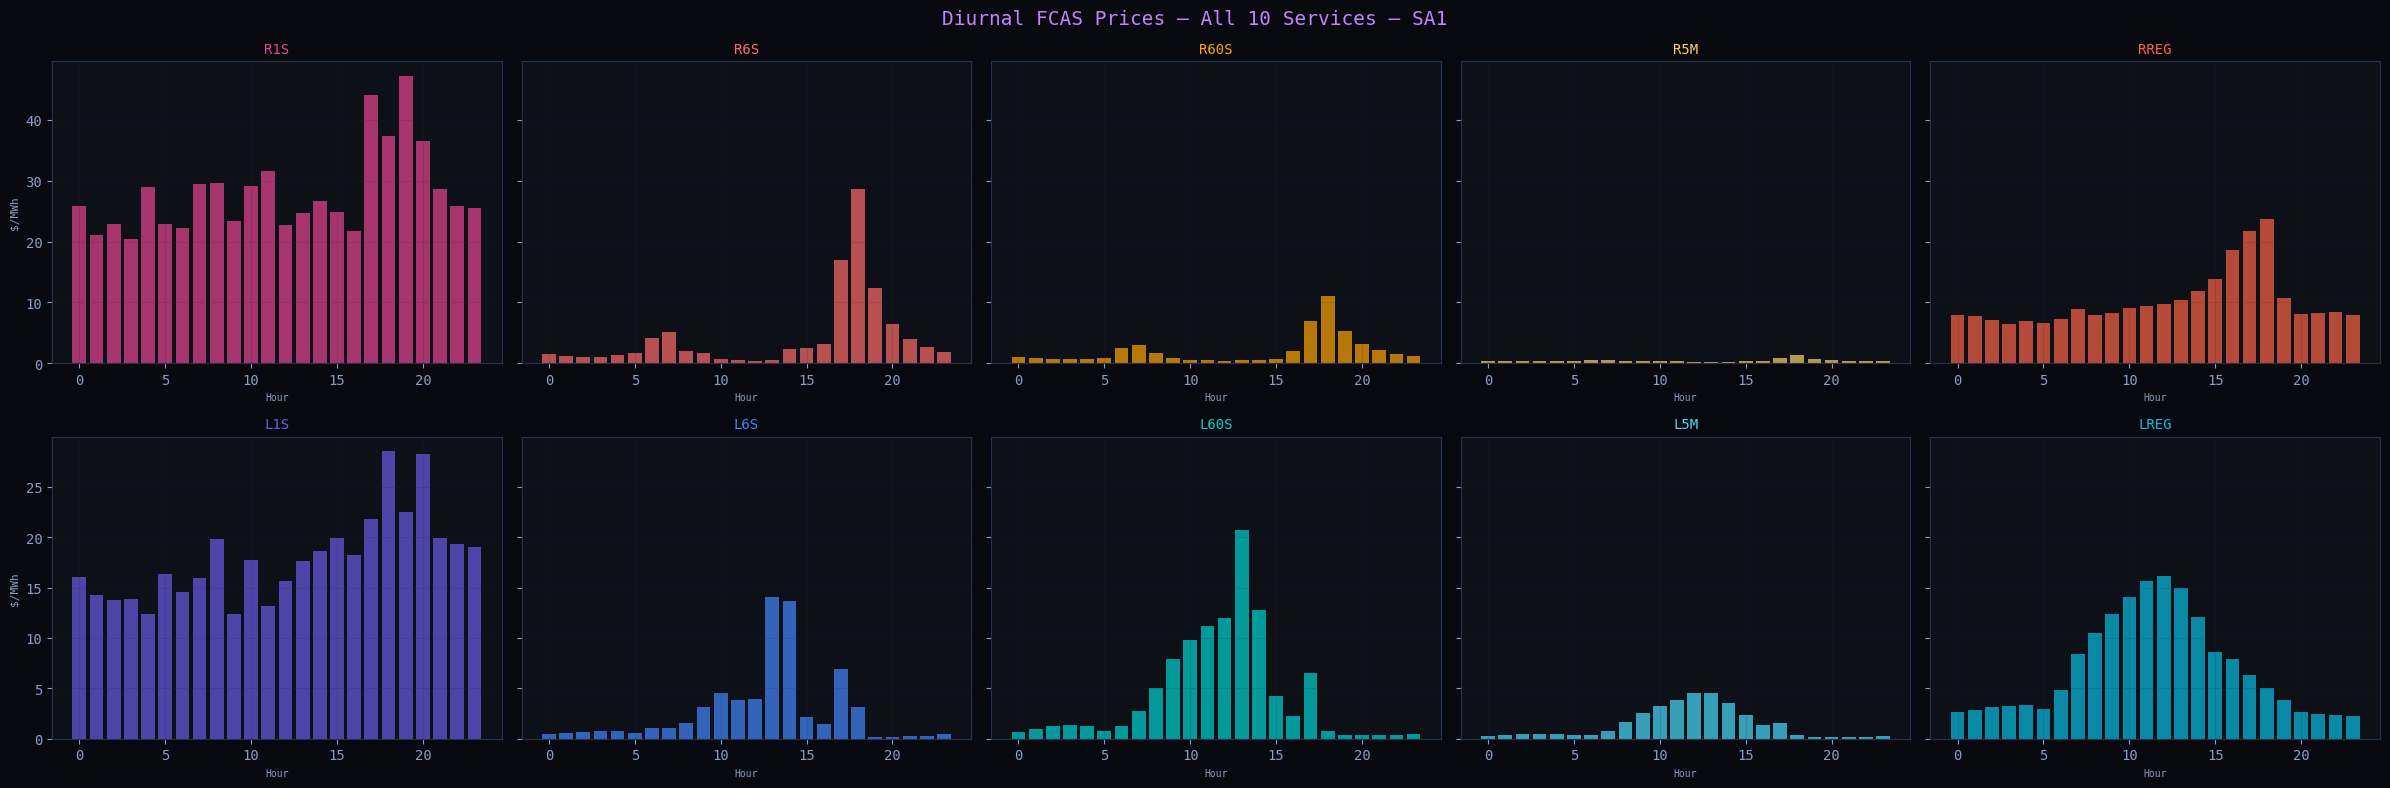


  Very Fast vs Fast Price Comparison:
    R1S/R6S: ratio=6.49x  corr=0.039  (VF mean=$28.06 vs Fast=$4.32)
    L1S/L6S: ratio=6.53x  corr=0.005  (VF mean=$17.91 vs Fast=$2.74)

  Autocorrelation (key lags):
     R1S: lag1=0.019  lag48=0.003  lag336=0.004
     R6S: lag1=0.562  lag48=0.048  lag336=0.057
    R60S: lag1=0.453  lag48=0.208  lag336=0.128
     R5M: lag1=0.608  lag48=0.203  lag336=0.295
    RREG: lag1=0.591  lag48=0.304  lag336=0.277
     L1S: lag1=0.045  lag48=0.004  lag336=0.008
     L6S: lag1=0.515  lag48=0.001  lag336=0.000
    L60S: lag1=0.419  lag48=0.008  lag336=0.006
     L5M: lag1=0.274  lag48=0.115  lag336=0.096
    LREG: lag1=0.670  lag48=0.447  lag336=0.394

  Temporal Split:
    Train: 29,414  |  Val: 3,676  |  Test (LOCKED): 3,678
    Target: 1,442 intervals (2025-01)


In [31]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEPS 3–4 — EDA + Temporal Split + Locked Test Set             ║
# ╚══════════════════════════════════════════════════════════════════╝

print('  STEPS 3–4 — EDA & VALIDATION STRATEGY')
print('  ' + '=' * 55)

# ── 3.1 Diurnal Pattern (10 services: 2 rows × 5 cols) ──────────
fig, axes = plt.subplots(2, 5, figsize=(24, 8), sharey='row')
fig.suptitle(f'Diurnal FCAS Prices — All 10 Services — {NEM_REGION}', fontsize=14, color='#c084fc')
for i, svc in enumerate(ACTIVE_SERVICES[:10]):
    ax = axes[i // 5, i % 5]
    hourly = df_fcas[svc].groupby(df_fcas.index.hour.values).mean()
    ax.bar(hourly.index, hourly.values, color=FCAS_META[svc]['color'], alpha=0.7)
    ax.set_title(FCAS_META[svc]['short'], fontsize=10, color=FCAS_META[svc]['color'])
    ax.set_xlabel('Hour', fontsize=7)
    if i % 5 == 0: ax.set_ylabel('$/MWh', fontsize=8)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('images/eda_diurnal_10svc.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3.2 Very Fast vs Fast comparison ─────────────────────────────
print('\n  Very Fast vs Fast Price Comparison:')
for pair in [('RAISE1SEC','RAISE6SEC'), ('LOWER1SEC','LOWER6SEC')]:
    vf, fast = pair
    if vf in df_fcas.columns and fast in df_fcas.columns:
        ratio = df_fcas[vf].mean() / max(df_fcas[fast].mean(), 0.01)
        corr  = df_fcas[vf].corr(df_fcas[fast])
        print(f'    {FCAS_META[vf]["short"]:>3s}/{FCAS_META[fast]["short"]}: '
              f'ratio={ratio:.2f}x  corr={corr:.3f}  '
              f'(VF mean=${df_fcas[vf].mean():.2f} vs Fast=${df_fcas[fast].mean():.2f})')

# ── 3.3 ACF key lags ─────────────────────────────────────────────
acf_lags = [1, 2, 6, 48, 336]
print('\n  Autocorrelation (key lags):')
for svc in ACTIVE_SERVICES:
    acfs = [f'{df_fcas[svc].autocorr(lag=l):.3f}' for l in acf_lags]
    print(f'    {FCAS_META[svc]["short"]:>4s}: lag1={acfs[0]}  lag48={acfs[3]}  lag336={acfs[4]}')

# ── 4. Temporal Split ────────────────────────────────────────────
target_start = pd.Timestamp(year=TARGET_YEAR, month=TARGET_MONTH, day=1)
target_end   = target_start + pd.offsets.MonthEnd(1) + pd.Timedelta('23h30min')

df_hist_energy = df_energy[df_energy.index < target_start].copy()
df_hist_fcas   = df_fcas[df_fcas.index < target_start].copy()
df_target_energy = df_energy[(df_energy.index >= target_start) & (df_energy.index <= target_end)].copy()
df_target_fcas   = df_fcas[(df_fcas.index >= target_start) & (df_fcas.index <= target_end)].copy()

n_hist  = len(df_hist_energy)
n_train = int(n_hist * 0.80)
n_val   = int(n_hist * 0.10)
n_test  = n_hist - n_train - n_val

class LockedTestSet:
    def __init__(self): self._evaluated = False
    def check(self):
        if self._evaluated: print("🚨 WARNING: Test set already evaluated")
        self._evaluated = True
test_guard = LockedTestSet()

print(f'\n  Temporal Split:')
print(f'    Train: {n_train:,}  |  Val: {n_val:,}  |  Test (LOCKED): {n_test:,}')
print(f'    Target: {len(df_target_energy):,} intervals ({TARGET_YEAR}-{TARGET_MONTH:02d})')

---
# PHASE 2 — REPRESENTATION

## STEPS 5–6 — Features & Pipeline

*(Same structure as before — extended to 10 services with cross-service VF features)*

In [32]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEPS 5–6 — Feature Engineering & Pipeline (10-service)        ║
# ╚══════════════════════════════════════════════════════════════════╝

print('  STEPS 5–6 — FEATURES & PIPELINE')
print('  ' + '=' * 55)

def _streak(cond):
    groups = (~cond).cumsum()
    return cond.groupby(groups).cumsum()

def build_features(df_e, df_f, target_svc):
    df = pd.DataFrame(index=df_e.index)
    p = df_f[target_svc]; e = df_e['price']
    d = df_e.get('demand', pd.Series(0, index=df_e.index))
    hour = df.index.hour + df.index.minute / 60.0
    
    # Cyclical + calendar
    df['sin_hour'] = np.sin(2*np.pi*hour/24)
    df['cos_hour'] = np.cos(2*np.pi*hour/24)
    df['sin_dow']  = np.sin(2*np.pi*df.index.dayofweek/7)
    df['cos_dow']  = np.cos(2*np.pi*df.index.dayofweek/7)
    df['hour'] = df.index.hour
    df['dow']  = df.index.dayofweek
    df['month']= df.index.month
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(float)
    df['solar_season'] = np.maximum(0, np.sin(2*np.pi*(df.index.dayofyear-80)/365))
    df['is_solar'] = ((hour >= 9) & (hour <= 16)).astype(float)
    df['solar_x_season'] = df['is_solar'] * df['solar_season']
    
    # Own-price lags & rolling
    for lag in [1,2,3,6,12,24,48,96,336]:
        df[f'fcas_lag_{lag}'] = p.shift(lag)
    ps = p.shift(1)
    for w in [6,12,24,48,96]:
        df[f'fcas_rm_{w}'] = ps.rolling(w, min_periods=1).mean()
        df[f'fcas_rs_{w}'] = ps.rolling(w, min_periods=1).std()
    df['fcas_rmax48'] = ps.rolling(48, min_periods=1).max()
    df['fcas_rmin48'] = ps.rolling(48, min_periods=1).min()
    for a in [0.1, 0.3, 0.5]:
        df[f'fcas_ewm_{a}'] = ps.ewm(alpha=a).mean()
    
    # Energy features
    es = e.shift(1)
    df['e_lag1']   = es; df['e_lag48'] = e.shift(48)
    df['e_rm24']   = es.rolling(24, min_periods=1).mean()
    df['e_neg']    = (es < 0).astype(float)
    df['e_spike']  = (es > 300).astype(float)
    
    # Demand
    ds = d.shift(1)
    df['d_lag1']  = ds; df['d_rm24'] = ds.rolling(24, min_periods=1).mean()
    
    # Cross-service features (sample of others, including VF ↔ Fast relationship)
    for other in ACTIVE_SERVICES:
        if other != target_svc and other in df_f.columns:
            short = FCAS_META[other]['short']
            df[f'x_{short}_l1'] = df_f[other].shift(1)
            df[f'x_{short}_rm24'] = df_f[other].shift(1).rolling(24, min_periods=1).mean()
    
    # Regime
    df['is_spike'] = (ps > ps.quantile(0.95)).astype(float)
    df['spike_streak'] = _streak(ps > ps.quantile(0.90))
    raise_cols = [s for s in RAISE_SERVICES if s in df_f.columns]
    lower_cols = [s for s in LOWER_SERVICES if s in df_f.columns]
    if raise_cols and lower_cols:
        rm = df_f[raise_cols].shift(1).mean(axis=1)
        lm = df_f[lower_cols].shift(1).mean(axis=1)
        df['rl_ratio'] = rm / (lm + 0.01)
    
    # Targets (raw, no log transform)
    df['target_raw'] = p.shift(-1)
    p99 = p.quantile(0.99); p01 = p.quantile(0.01)
    df['target_winsorised'] = p.shift(-1).clip(lower=p01, upper=p99)
    return df

class FeaturePipeline:
    def __init__(self): self.scaler = None; self.feature_cols_ = None; self.fitted = False
    def fit(self, df, feat_cols):
        self.feature_cols_ = feat_cols
        self.scaler = RobustScaler()
        self.scaler.fit(df[feat_cols].dropna())
        self.fitted = True; return self
    def transform(self, df):
        df_f = df.copy()
        df_f[self.feature_cols_] = self.scaler.transform(df_f[self.feature_cols_])
        tgt = [c for c in ('target_raw','target_winsorised') if c in df_f.columns]
        return df_f.dropna(subset=self.feature_cols_ + tgt)

def score(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not mask.all(): y_true, y_pred = y_true[mask], y_pred[mask]
    if len(y_true) < 2: return dict(mae=np.nan, rmse=np.nan, mape=np.nan, da=np.nan, r2=np.nan)
    return dict(
        mae=mean_absolute_error(y_true,y_pred),
        rmse=np.sqrt(mean_squared_error(y_true,y_pred)),
        mape=np.mean(np.abs((y_true-y_pred)/(np.abs(y_true)+1)))*100,
        da=np.mean(np.sign(np.diff(y_true))==np.sign(np.diff(y_pred)))*100,
        r2=r2_score(y_true,y_pred),
    )

# Demo
demo_feat = build_features(df_hist_energy, df_hist_fcas, ACTIVE_SERVICES[0])
feat_cols_demo = [c for c in demo_feat.columns if c not in ('target_raw','target_winsorised')]
print(f'  Total features per service: {len(feat_cols_demo)}')
print(f'  ✓ Pipeline ready')

  STEPS 5–6 — FEATURES & PIPELINE
  Total features per service: 63
  ✓ Pipeline ready


---
# PHASE 3 — MODELLING

## STEPS 7–9 — Baselines → Model Training → Ensemble

*(Per-service XGBoost + LightGBM + Ensemble — all 10 services)*

In [33]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEPS 7–9 — Baselines + Model Training (10 services)          ║
# ╚══════════════════════════════════════════════════════════════════╝

print('  STEPS 7–9 — BASELINES & MODEL TRAINING')
print('  ' + '=' * 55)

all_models = {}; all_pipes = {}; all_feat_cols = {}
val_results = {}; best_baselines = {}

for svc in ACTIVE_SERVICES:
    print(f'\n  ── {FCAS_META[svc]["short"]} ({FCAS_META[svc]["category"]}) ──')
    df_feat = build_features(df_hist_energy, df_hist_fcas, svc)
    fc = [c for c in df_feat.columns if c not in ('target_raw','target_winsorised')]
    
    pipe = FeaturePipeline().fit(df_feat.iloc[:n_train], fc)
    df_tr = pipe.transform(df_feat.iloc[:n_train])
    df_vl = pipe.transform(df_feat.iloc[n_train:n_train+n_val])
    X_tr, y_tr = df_tr[fc].values, df_tr['target_raw'].values
    X_vl, y_vl = df_vl[fc].values, df_vl['target_raw'].values
    
    # Baseline (seasonal naive 48)
    p_h = df_hist_fcas[svc]
    bl_pred = p_h.shift(48).iloc[n_train:n_train+n_val]
    bl_act  = p_h.iloc[n_train:n_train+n_val]
    m = np.isfinite(bl_act) & np.isfinite(bl_pred)
    bl_mae = mean_absolute_error(bl_act[m], bl_pred[m]) if m.sum()>10 else 999
    best_baselines[svc] = {'method':'seasonal_48','mae':bl_mae}
    print(f'    Baseline (seasonal_48): MAE=${bl_mae:.2f}')
    
    svc_models = {}; svc_scores = {}
    
    # XGBoost
    if 'XGBoost' in MODEL_OPTIONS and DEPS.get('xgboost'):
        import xgboost as xgb
        m_xgb = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
        m_xgb.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
        s = score(y_vl, m_xgb.predict(X_vl))
        svc_models['xgb'] = m_xgb; svc_scores['xgb'] = s
        print(f'    XGBoost:  MAE=${s["mae"]:.2f}  R²={s["r2"]:.4f}')
    
    # LightGBM
    if 'LightGBM' in MODEL_OPTIONS and DEPS.get('lightgbm'):
        import lightgbm as lgb
        m_lgb = lgb.LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
        m_lgb.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], callbacks=[lgb.log_evaluation(-1)])
        s = score(y_vl, m_lgb.predict(X_vl))
        svc_models['lgb'] = m_lgb; svc_scores['lgb'] = s
        print(f'    LightGBM: MAE=${s["mae"]:.2f}  R²={s["r2"]:.4f}')
    
    # Ensemble
    if len(svc_models) >= 2 and 'Ensemble' in MODEL_OPTIONS:
        inv = {n: 1.0/svc_scores[n]['mae'] for n in svc_models}
        tot = sum(inv.values())
        wts = {n: v/tot for n, v in inv.items()}
        pred_ens = sum(wts[n]*svc_models[n].predict(X_vl) for n in svc_models)
        s = score(y_vl, pred_ens)
        svc_scores['ensemble'] = s; svc_models['weights'] = wts
        print(f'    Ensemble: MAE=${s["mae"]:.2f}  R²={s["r2"]:.4f}  wts={wts}')
    
    best_ml = min(sc['mae'] for sc in svc_scores.values())
    imp = (bl_mae - best_ml) / bl_mae * 100
    print(f'    vs Baseline: {imp:+.1f}% {"✓" if imp > 0 else "⚠"}')
    
    all_models[svc] = svc_models; all_pipes[svc] = pipe
    all_feat_cols[svc] = fc; val_results[svc] = svc_scores

with open('models/fcas10_models.pkl','wb') as f:
    pickle.dump({'models':all_models,'pipes':all_pipes,'feat_cols':all_feat_cols}, f)
print(f'\n  ✓ All 10-service models trained & saved')

  STEPS 7–9 — BASELINES & MODEL TRAINING

  ── R1S (very_fast) ──
    Baseline (seasonal_48): MAE=$39.77
    XGBoost:  MAE=$50.78  R²=-1.6600
    LightGBM: MAE=$48.73  R²=-0.7198
    Ensemble: MAE=$47.13  R²=-0.8251  wts={'xgb': 0.48969308576974596, 'lgb': 0.5103069142302541}
    vs Baseline: -18.5% ⚠

  ── R6S (fast) ──
    Baseline (seasonal_48): MAE=$9.84
    XGBoost:  MAE=$5.54  R²=0.1205
    LightGBM: MAE=$5.50  R²=0.0744
    Ensemble: MAE=$5.49  R²=0.0980  wts={'xgb': 0.49799699899051353, 'lgb': 0.5020030010094865}
    vs Baseline: +44.2% ✓

  ── R60S (slow) ──
    Baseline (seasonal_48): MAE=$0.42
    XGBoost:  MAE=$2.24  R²=-113.7673
    LightGBM: MAE=$3.21  R²=-64.4986
    Ensemble: MAE=$2.52  R²=-77.3530  wts={'xgb': 0.5884868465432682, 'lgb': 0.4115131534567319}
    vs Baseline: -435.0% ⚠

  ── R5M (delayed) ──
    Baseline (seasonal_48): MAE=$0.13
    XGBoost:  MAE=$0.20  R²=-1.7386
    LightGBM: MAE=$0.15  R²=-0.0861
    Ensemble: MAE=$0.17  R²=-0.5674  wts={'xgb': 0.42886

---
# PHASE 4 — EVALUATION

## STEP 10 — Diagnostics & SHAP (condensed)

  STEP 10 — DIAGNOSTICS (10 services)
   Svc       Cat      MAE     RMSE       R²   vs BL
  ────────────────────────────────────────────────
   R1S very_fast $ 48.02 $160.99 -0.1880  -20.8%
   R6S      fast $  2.86 $ 68.45  0.0299  +70.9%
  R60S      slow $  1.53 $ 13.32 -210.5702 -264.1%
   R5M   delayed $  0.07 $  0.15 -1.6741  +44.3%
  RREG regulation $  2.97 $  4.49  0.1867  +44.1%
   L1S very_fast $ 22.87 $ 67.27 -0.1500  +13.6%
   L6S      fast $178.89 $786.30 -145874.5385 -1655.0%
  L60S      slow $ 48.55 $301.39 -5500.5591 -673.9%
   L5M   delayed $  0.48 $  1.55 -10.1322  +62.3%
  LREG regulation $  2.15 $  3.37 -0.2513  +38.7%


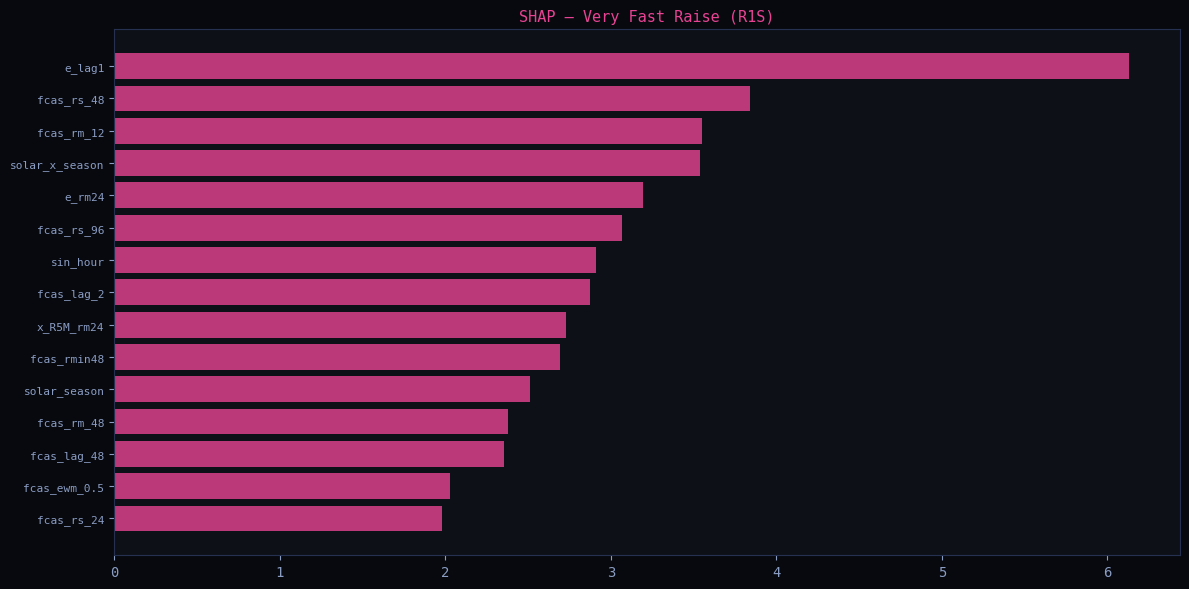


  Top features (R1S): e_lag1, fcas_rs_48, fcas_rm_12, solar_x_season, e_rm24

  ✓ Test set evaluated ONCE — diagnostics complete


In [34]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 10 — One-Time Test Set + SHAP (10 services)              ║
# ╚══════════════════════════════════════════════════════════════════╝

print('  STEP 10 — DIAGNOSTICS (10 services)')
print('  ' + '=' * 55)
test_guard.check()

test_results = {}
print(f'  {"Svc":>4s} {"Cat":>9s} {"MAE":>8s} {"RMSE":>8s} {"R²":>8s} {"vs BL":>7s}')
print(f'  {"─"*48}')
for svc in ACTIVE_SERVICES:
    df_ft = build_features(df_hist_energy, df_hist_fcas, svc)
    df_te = all_pipes[svc].transform(df_ft.iloc[n_train+n_val:])
    if len(df_te)==0: continue
    Xt, yt = df_te[all_feat_cols[svc]].values, df_te['target_raw'].values
    m = all_models[svc]
    if 'weights' in m:
        pt = sum(m['weights'][n]*m[n].predict(Xt) for n in m if n!='weights')
    elif 'xgb' in m: pt = m['xgb'].predict(Xt)
    else: pt = m['lgb'].predict(Xt)
    s = score(yt, pt); test_results[svc] = s
    imp = (best_baselines[svc]['mae']-s['mae'])/best_baselines[svc]['mae']*100
    print(f'  {FCAS_META[svc]["short"]:>4s} {FCAS_META[svc]["category"]:>9s} '
          f'${s["mae"]:>6.2f} ${s["rmse"]:>6.2f} {s["r2"]:>7.4f} {imp:>+6.1f}%')

# SHAP for R1S (Very Fast) if available
if DEPS.get('shap') and 'RAISE1SEC' in all_models:
    import shap
    demo = 'RAISE1SEC'
    dm = all_models[demo].get('xgb', all_models[demo].get('lgb'))
    df_sh = build_features(df_hist_energy, df_hist_fcas, demo)
    df_sh_t = all_pipes[demo].transform(df_sh.iloc[:n_train])
    Xs = df_sh_t[all_feat_cols[demo]].values
    n_s = min(500, len(Xs))
    expl = shap.TreeExplainer(dm)
    sv = expl.shap_values(Xs[np.random.choice(len(Xs), n_s, replace=False)])
    fi = np.abs(sv).mean(axis=0)
    top_i = np.argsort(fi)[-15:][::-1]
    top_n = [all_feat_cols[demo][i] for i in top_i]
    fig, ax = plt.subplots(figsize=(12,6))
    ax.barh(range(len(top_n)), fi[top_i][::-1], color='#e84393', alpha=0.8)
    ax.set_yticks(range(len(top_n))); ax.set_yticklabels(top_n[::-1], fontsize=8)
    ax.set_title(f'SHAP — Very Fast Raise (R1S)', color='#e84393')
    plt.tight_layout(); plt.savefig('images/shap_r1s.png', dpi=150, bbox_inches='tight'); plt.show()
    print(f'\n  Top features (R1S): {", ".join(top_n[:5])}')

print('\n  ✓ Test set evaluated ONCE — diagnostics complete')

---
# PHASE 5 — PRODUCTION

## STEP 11 — Forecast + STEP 11b — 10-Band Bid Generation

### Theory: AEMO 10 Price-Quantity Bid Band Construction

For each service $s$ at each trading interval $t$, we construct 10 bid bands:

$$\text{BP}_b = (\lambda_b, q_b) \quad \text{for } b = 1, \ldots, 10$$

**Price bands** are derived from the forecast price distribution:
- $\lambda_1 = 0$ (floor — guarantees enablement)
- $\lambda_b = F^{-1}_{\hat{\lambda}_s}(p_b)$ where $p_b$ is the percentile for band $b$
- $\lambda_{10} = \min(F^{-1}(0.99), \text{MPC})$

**Quantity allocation** distributes available MW across bands:
- Low bands (BP1–BP3): 50% MW → high-confidence enablement
- Mid bands (BP4–BP7): 30% MW → selective dispatch
- High bands (BP8–BP10): 20% MW → spike capture premium

**Constraints enforced:**
- $\sum_{b=1}^{10} q_b = \text{MaxAvailability}_s$
- $\lambda_1 \leq \lambda_2 \leq \ldots \leq \lambda_{10}$ (monotonic)
- $\sum_{s \in \text{Raise}} \text{MaxAvail}_s + |P_{\text{energy}}| \leq P_{\max}$ (power limit)
- SoC and FCAS trapezium constraints

In [35]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 11 — Forecast + STEP 11b — 10-Band Bid Generation        ║
# ╚══════════════════════════════════════════════════════════════════╝

print('  STEP 11 — FORECAST + 10-BAND BID GENERATION')
print('  ' + '=' * 55)

# ── 11a. Seasonal Anchor Forecast ────────────────────────────────
def _build_anchor(hist_s, t_idx):
    t0 = t_idx[0]
    ae = t0 - pd.DateOffset(weeks=52)
    astart = ae - pd.DateOffset(weeks=6)
    ar = hist_s[(hist_s.index>=astart)&(hist_s.index<ae)]
    if len(ar)<48: ar = hist_s.iloc[-336:]
    sc = hist_s.iloc[-48*14:].mean() / (ar.mean()+1e-6)
    res = {}
    for t in t_idx:
        slot = ar[(ar.index.hour==t.hour)&(ar.index.minute==t.minute)&(ar.index.dayofweek==t.dayofweek)]
        if len(slot)==0: slot = ar[(ar.index.hour==t.hour)&(ar.index.minute==t.minute)]
        res[t] = float(slot.mean()*sc) if len(slot)>0 else float(hist_s.iloc[-48:].mean())
    return pd.Series(res)

def forecast_svc(svc, df_he, df_hf, t_idx):
    models=all_models[svc]; pipe=all_pipes[svc]; fc=all_feat_cols[svc]
    anchor = _build_anchor(df_hf[svc], t_idx)
    tail = 400
    wk_e = df_he.iloc[-tail:].copy(); wk_f = df_hf.iloc[-tail:].copy()
    for t in t_idx:
        if t not in wk_f.index:
            wk_f.loc[t] = {s: anchor.get(t, df_hf[s].iloc[-48:].mean()) for s in wk_f.columns}
            ea = _build_anchor(df_he['price'], pd.DatetimeIndex([t]))
            wk_e.loc[t] = {'price':ea.iloc[0], 'demand':df_he['demand'].iloc[-48:].mean() if 'demand' in df_he else 0}
    wk_f = wk_f.sort_index(); wk_e = wk_e.sort_index()
    forecasts = {}
    for t in t_idx:
        df_ft = build_features(wk_e.loc[:t], wk_f.loc[:t], svc)
        if len(df_ft)<2: forecasts[t]=anchor.get(t,0); continue
        lr = df_ft.iloc[[-1]].copy()
        for c in fc:
            if c in lr.columns and lr[c].isna().any(): lr[c]=0
        try:
            Xp = pipe.scaler.transform(lr[fc].values.reshape(1,-1))
            if 'weights' in models:
                pred = sum(models['weights'][n]*models[n].predict(Xp)[0] for n in models if n!='weights')
            elif 'xgb' in models: pred = models['xgb'].predict(Xp)[0]
            elif 'lgb' in models: pred = models['lgb'].predict(Xp)[0]
            else: pred = anchor.get(t,0)
            pred = max(0, pred)
        except: pred = anchor.get(t,0)
        forecasts[t] = pred; wk_f.loc[t, svc] = pred
    return pd.Series(forecasts, name=svc)

# Forecast all 10 services
t_idx = pd.date_range(target_start, target_end, freq='30min')
if TARGET_WEEK:
    ws = target_start + pd.Timedelta(days=(TARGET_WEEK-1)*7)
    we = min(ws + pd.Timedelta(days=7) - pd.Timedelta('30min'), target_end)
    t_idx = t_idx[(t_idx>=ws)&(t_idx<=we)]

df_forecast = pd.DataFrame(index=t_idx)
for svc in ACTIVE_SERVICES:
    t0 = time.time()
    fc = forecast_svc(svc, df_hist_energy, df_hist_fcas, t_idx)
    df_forecast[svc] = fc
    print(f'  {FCAS_META[svc]["short"]:>4s}: mean=${fc.mean():.2f} p50=${fc.median():.2f} ({time.time()-t0:.1f}s)')

e_anchor = _build_anchor(df_hist_energy['price'], t_idx)
df_forecast['energy_price'] = e_anchor

# ══════════════════════════════════════════════════════════════════
#  11b. 10 PRICE-QUANTITY BID BAND GENERATION (AEMO FORMAT)
# ══════════════════════════════════════════════════════════════════
#
#  For each service s, each interval t, output:
#    BP1_price, BP1_qty, BP2_price, BP2_qty, ..., BP10_price, BP10_qty
#
#  AEMO dispatch (NEMDE) enables from cheapest band first.
#  Our strategy:
#    - Price bands from forecast distribution percentiles
#    - Quantity split: low bands get more MW (higher chance of enablement)
#    - MaxAvailability per service limited by power headroom

print(f'\n  Generating 10-band bid schedule ...')

def generate_bid_bands(df_fc, bess, active_svcs):
    """
    Generate AEMO-format 10 price-quantity bid bands for all services.
    
    Returns:
        bid_bands: dict {service: DataFrame with columns BP1_price..BP10_price, BP1_qty..BP10_qty}
        summary:   DataFrame with MaxAvail and revenue per service per interval
    """
    T = len(df_fc)
    dt = bess.dt_hours
    
    # State
    E = np.zeros(T+1); E[0] = bess.E_init
    soc_trace = pd.Series(0.0, index=df_fc.index, name='soc')
    
    # Storage for bid bands and revenue
    bid_bands = {svc: pd.DataFrame(index=df_fc.index) for svc in active_svcs}
    revenue   = pd.DataFrame(0.0, index=df_fc.index, columns=active_svcs + ['energy','total'])
    max_avail = pd.DataFrame(0.0, index=df_fc.index, columns=active_svcs)
    
    # Pre-compute price distribution percentiles per service (from training data)
    price_percentiles = {}
    for svc in active_svcs:
        hist_prices = df_hist_fcas[svc].dropna()
        pcts = [np.percentile(hist_prices, p) if p > 0 else BID_PRICE_FLOOR 
                for p in BID_BAND_PERCENTILES]
        # Ensure monotonic ascending
        for i in range(1, len(pcts)):
            pcts[i] = max(pcts[i], pcts[i-1] + 0.01)
        # Cap BP10 at MPC
        pcts[-1] = min(pcts[-1], BID_PRICE_CAP)
        price_percentiles[svc] = pcts
    
    for t in range(T):
        P_avail = bess.power_mw
        raise_headroom = max(0, (E[t] - bess.E_min) / dt * bess.eta_discharge)
        lower_headroom = max(0, (bess.E_max - E[t]) / dt * bess.eta_charge)
        
        # Rank services by forecast price (highest first)
        prices_t = {svc: df_fc[svc].iloc[t] for svc in active_svcs}
        ranked = sorted(prices_t.items(), key=lambda x: x[1], reverse=True)
        
        total_raise = 0; total_lower = 0
        
        for svc, fc_price in ranked:
            if P_avail <= 0: break
            is_raise = 'RAISE' in svc
            
            if is_raise:
                avail_mw = min(P_avail, raise_headroom - total_raise)
            else:
                avail_mw = min(P_avail, lower_headroom - total_lower)
            avail_mw = max(0, min(avail_mw, bess.power_mw * 0.35))
            
            if fc_price > 0.10 and avail_mw > 0:
                max_avail.loc[df_fc.index[t], svc] = avail_mw
                
                # ── BUILD 10 BID BANDS ─────────────────────────────
                band_prices = price_percentiles[svc].copy()
                
                # Adjust mid-band prices around current forecast
                # BP5 (median band) = forecast price
                band_prices[4] = max(band_prices[3] + 0.01, fc_price)
                for i in range(5, N_BID_BANDS):
                    band_prices[i] = max(band_prices[i], band_prices[i-1] + 0.01)
                band_prices[-1] = min(band_prices[-1], BID_PRICE_CAP)
                
                # Quantity allocation: weighted split of available MW
                band_qtys = [round(avail_mw * w, 2) for w in BID_QTY_WEIGHTS]
                # Fix rounding: ensure sum == avail_mw
                residual = avail_mw - sum(band_qtys)
                band_qtys[0] += residual
                
                # Store in DataFrame
                for b in range(N_BID_BANDS):
                    bid_bands[svc].loc[df_fc.index[t], f'BP{b+1}_price'] = round(band_prices[b], 2)
                    bid_bands[svc].loc[df_fc.index[t], f'BP{b+1}_qty']   = round(band_qtys[b], 2)
                bid_bands[svc].loc[df_fc.index[t], 'MaxAvail']    = round(avail_mw, 2)
                bid_bands[svc].loc[df_fc.index[t], 'ForecastPrice'] = round(fc_price, 2)
                
                # Revenue estimate (assume full enablement at forecast price)
                revenue.loc[df_fc.index[t], svc] = avail_mw * fc_price * dt
                
                if is_raise: total_raise += avail_mw
                else:        total_lower += avail_mw
                P_avail -= avail_mw
        
        # Energy dispatch with remaining capacity
        ep = df_fc['energy_price'].iloc[t] if 'energy_price' in df_fc.columns else 0
        if ep < -10 and P_avail > 0:
            ch = min(P_avail, lower_headroom - total_lower); ch = max(0, ch)
            E[t+1] = E[t] + ch * bess.eta_charge * dt
            revenue.loc[df_fc.index[t], 'energy'] = ch * abs(ep) * dt
        elif ep > bess.breakeven_spread and P_avail > 0:
            dc = min(P_avail, raise_headroom - total_raise); dc = max(0, dc)
            E[t+1] = E[t] - dc / bess.eta_discharge * dt
            revenue.loc[df_fc.index[t], 'energy'] = dc * ep * dt
        else:
            E[t+1] = E[t]
        
        E[t+1] = np.clip(E[t+1], bess.E_min, bess.E_max)
        soc_trace.iloc[t] = E[t] / bess.capacity_mwh
        revenue.loc[df_fc.index[t], 'total'] = revenue.loc[df_fc.index[t], active_svcs + ['energy']].sum()
    
    return bid_bands, revenue, soc_trace, max_avail

bid_bands, revenue, soc_trace, max_avail = generate_bid_bands(df_forecast, BESS, ACTIVE_SERVICES)

# ── Print Bid Band Sample ────────────────────────────────────────
total_rev = revenue['total'].sum()
fcas_rev  = revenue[ACTIVE_SERVICES].sum().sum()
energy_rev= revenue['energy'].sum()

print(f'\n  BID GENERATION RESULTS')
print(f'  {"─"*60}')
print(f'  Total Revenue:  ${total_rev:>12,.0f}')
print(f'  FCAS Revenue:   ${fcas_rev:>12,.0f} ({fcas_rev/max(total_rev,1)*100:.1f}%)')
print(f'  Energy Revenue: ${energy_rev:>12,.0f} ({energy_rev/max(total_rev,1)*100:.1f}%)')
print(f'  {"─"*60}')
print(f'  Revenue per Service:')
for svc in ACTIVE_SERVICES:
    sr = revenue[svc].sum()
    am = max_avail[svc].mean()
    print(f'    {FCAS_META[svc]["short"]:>4s} ({FCAS_META[svc]["category"]:>9s}): '
          f'${sr:>10,.0f}  avg_avail={am:.1f}MW')

# ── Sample bid band display ──────────────────────────────────────
sample_svc = ACTIVE_SERVICES[0]
sample_t   = df_forecast.index[24]  # noon-ish
print(f'\n  SAMPLE BID BANDS — {FCAS_META[sample_svc]["short"]} @ {sample_t}')
print(f'  {"Band":>6s}  {"Price $/MWh":>12s}  {"Qty MW":>8s}')
print(f'  {"─"*30}')
for b in range(N_BID_BANDS):
    bp = bid_bands[sample_svc].loc[sample_t, f'BP{b+1}_price']
    bq = bid_bands[sample_svc].loc[sample_t, f'BP{b+1}_qty']
    if not np.isnan(bp):
        print(f'  BP{b+1:>3d}   ${bp:>10.2f}   {bq:>7.2f}')
ma = bid_bands[sample_svc].loc[sample_t, 'MaxAvail']
print(f'  {"─"*30}')
print(f'  {"Total":>6s}  {"":>12s}  {ma:>7.2f} MW')
print(f'\n  ✓ 10-band bid schedule generated for {len(ACTIVE_SERVICES)} services × {len(t_idx)} intervals')

  STEP 11 — FORECAST + 10-BAND BID GENERATION
   R1S: mean=$212.48 p50=$199.30 (168.4s)
   R6S: mean=$149.03 p50=$151.80 (166.1s)
  R60S: mean=$55.63 p50=$54.13 (166.1s)
   R5M: mean=$32.94 p50=$40.33 (166.0s)
  RREG: mean=$65.59 p50=$55.13 (166.2s)
   L1S: mean=$334.55 p50=$342.52 (170.8s)
   L6S: mean=$186.48 p50=$126.43 (167.8s)
  L60S: mean=$83.65 p50=$75.05 (165.9s)
   L5M: mean=$23.60 p50=$25.23 (166.6s)
  LREG: mean=$48.25 p50=$51.29 (170.0s)

  Generating 10-band bid schedule ...

  BID GENERATION RESULTS
  ────────────────────────────────────────────────────────────
  Total Revenue:  $  20,259,324
  FCAS Revenue:   $  20,259,324 (100.0%)
  Energy Revenue: $           0 (0.0%)
  ────────────────────────────────────────────────────────────
  Revenue per Service:
     R1S (very_fast): $ 5,014,700  avg_avail=29.7MW
     R6S (     fast): $ 2,491,437  avg_avail=20.7MW
    R60S (     slow): $         0  avg_avail=0.0MW
     R5M (  delayed): $         0  avg_avail=0.0MW
    RREG (regu

---
## STEP 12 — Dashboard + CSV Exports + Bid Band Files

  STEP 12 — DASHBOARD & EXPORTS


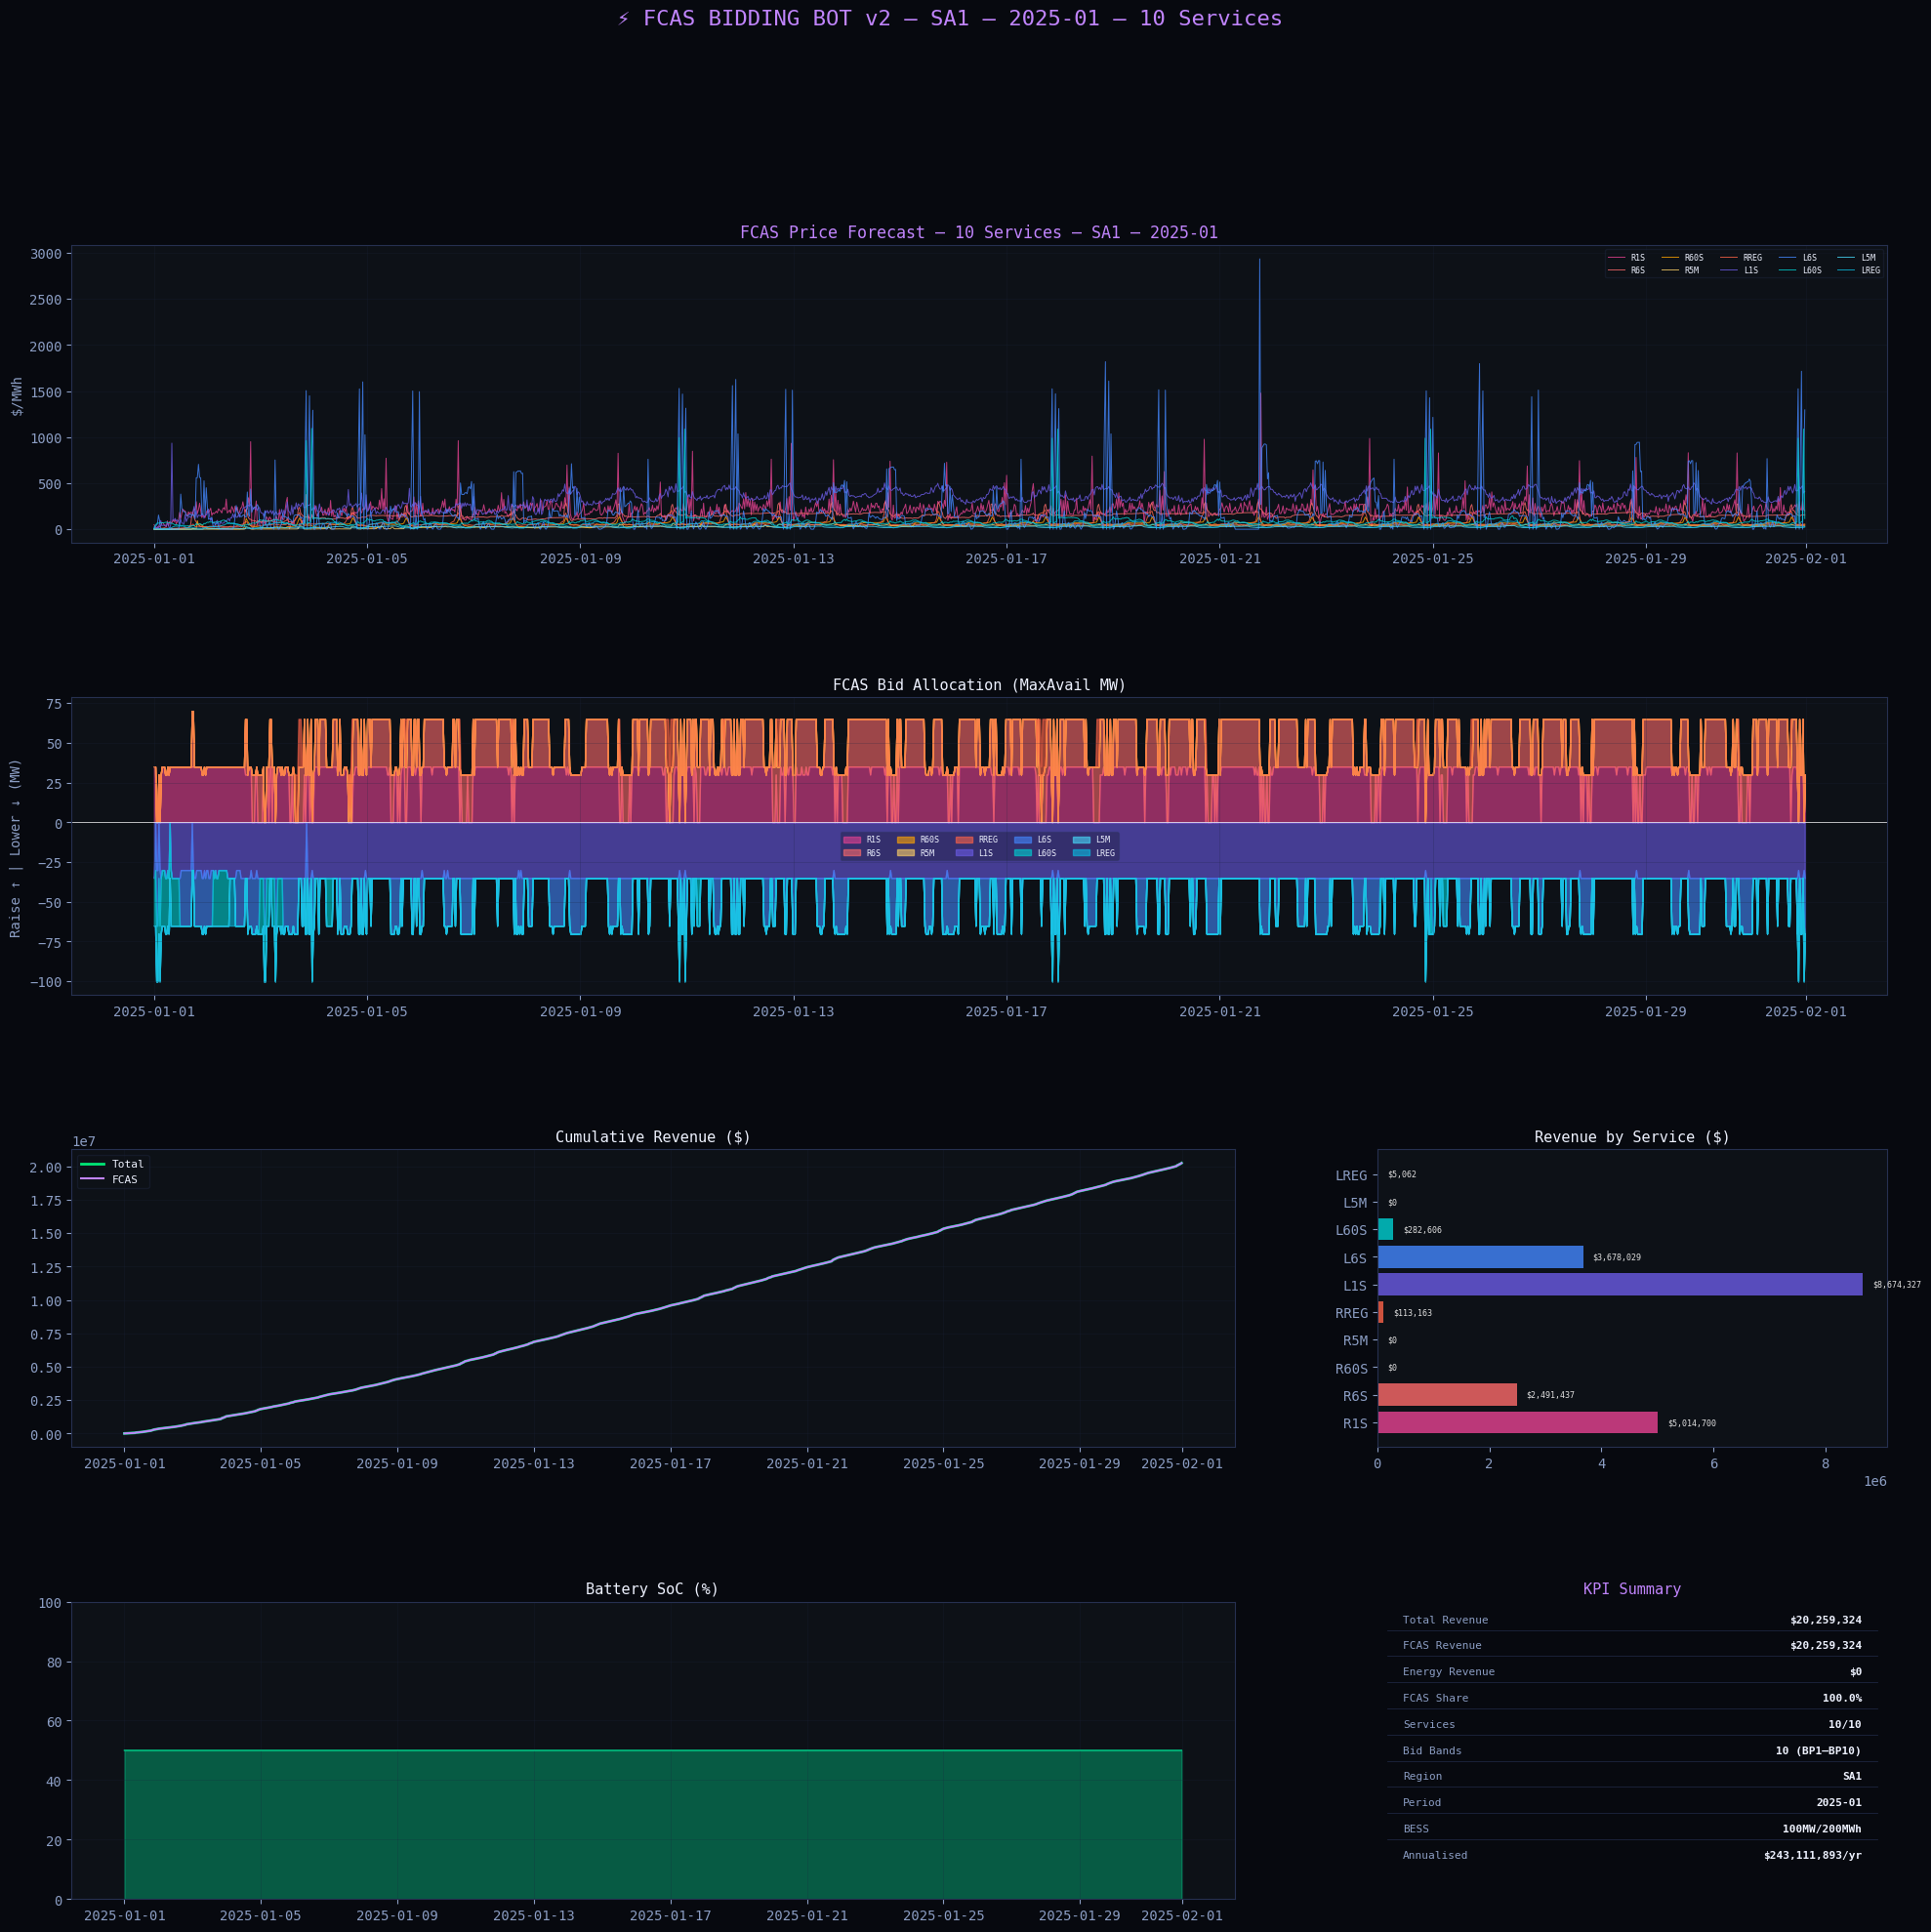


  Exporting AEMO-format bid band files ...
    ✓ outputs/bid_bands_R1S_SA1_202501.csv
    ✓ outputs/bid_bands_R6S_SA1_202501.csv
    ✓ outputs/bid_bands_R60S_SA1_202501.csv
    ✓ outputs/bid_bands_R5M_SA1_202501.csv
    ✓ outputs/bid_bands_RREG_SA1_202501.csv
    ✓ outputs/bid_bands_L1S_SA1_202501.csv
    ✓ outputs/bid_bands_L6S_SA1_202501.csv
    ✓ outputs/bid_bands_L60S_SA1_202501.csv
    ✓ outputs/bid_bands_L5M_SA1_202501.csv
    ✓ outputs/bid_bands_LREG_SA1_202501.csv

  CSV Exports Summary:
    - fcas_price_forecast_10svc.csv  (1488 × 11 cols)
    - fcas_revenue_10svc.csv
    - soc_trace.csv
    - bid_bands_[SVC]_*.csv          (10 files, one per service)
    - bid_bands_ALL_SERVICES.csv     (combined: 154 cols)
    - max_availability.csv
    - dashboard_fcas10.png

  ✓ All exports complete


In [36]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 12 — Dashboard (6-panel) + CSV Exports                    ║
# ╚══════════════════════════════════════════════════════════════════╝

print('  STEP 12 — DASHBOARD & EXPORTS')
print('  ' + '=' * 55)

fig = plt.figure(figsize=(24, 22))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.28)
ax1 = fig.add_subplot(gs[0, :])   # FCAS prices
ax2 = fig.add_subplot(gs[1, :])   # Bid allocation
ax3 = fig.add_subplot(gs[2, :2])  # Cumulative revenue
ax4 = fig.add_subplot(gs[2, 2])   # Revenue by service
ax5 = fig.add_subplot(gs[3, :2])  # SoC
ax6 = fig.add_subplot(gs[3, 2])   # KPIs
ax6.axis('off')

# P1: FCAS prices (10 services)
for svc in ACTIVE_SERVICES:
    ax1.plot(df_forecast.index, df_forecast[svc], color=FCAS_META[svc]['color'],
             label=FCAS_META[svc]['short'], lw=0.7, alpha=0.8)
ax1.set_title(f'FCAS Price Forecast — 10 Services — {NEM_REGION} — {TARGET_YEAR}-{TARGET_MONTH:02d}',
              fontsize=12, color='#c084fc')
ax1.set_ylabel('$/MWh'); ax1.legend(ncol=5, fontsize=6); ax1.grid(True, alpha=0.3)

# P2: Max availability allocation
br = np.zeros(len(max_avail)); bl = np.zeros(len(max_avail))
for svc in ACTIVE_SERVICES:
    vals = max_avail[svc].values
    if 'RAISE' in svc:
        ax2.fill_between(max_avail.index, br, br+vals, color=FCAS_META[svc]['color'], alpha=0.6, label=FCAS_META[svc]['short'])
        br += vals
    else:
        ax2.fill_between(max_avail.index, -bl-vals, -bl, color=FCAS_META[svc]['color'], alpha=0.6, label=FCAS_META[svc]['short'])
        bl += vals
ax2.axhline(0, color='white', lw=0.5)
ax2.set_title('FCAS Bid Allocation (MaxAvail MW)', fontsize=11)
ax2.set_ylabel('Raise ↑ | Lower ↓ (MW)'); ax2.legend(ncol=5, fontsize=6); ax2.grid(True, alpha=0.3)

# P3: Cumulative revenue
ax3.plot(revenue.index, revenue['total'].cumsum(), color=C['revenue'], lw=2, label='Total')
ax3.plot(revenue.index, revenue[ACTIVE_SERVICES].sum(axis=1).cumsum(), color=C['forecast'], lw=1.5, label='FCAS')
ax3.set_title('Cumulative Revenue ($)'); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# P4: Revenue by service (bar)
svc_revs = {FCAS_META[s]['short']: revenue[s].sum() for s in ACTIVE_SERVICES}
colors_b = [FCAS_META[s]['color'] for s in ACTIVE_SERVICES]
ax4.barh(list(svc_revs.keys()), list(svc_revs.values()), color=colors_b, alpha=0.8)
ax4.set_title('Revenue by Service ($)', fontsize=11)
for i, (n, v) in enumerate(svc_revs.items()):
    ax4.text(v + max(svc_revs.values())*0.02, i, f'${v:,.0f}', va='center', fontsize=6, color='#e0e0e0')

# P5: SoC
ax5.fill_between(soc_trace.index, 0, soc_trace.values*100, color=C['soc'], alpha=0.4)
ax5.plot(soc_trace.index, soc_trace.values*100, color=C['soc'], lw=1)
ax5.set_title('Battery SoC (%)'); ax5.set_ylim(0,100); ax5.grid(True, alpha=0.3)

# P6: KPIs
kpis = [
    ('Total Revenue',   f'${total_rev:,.0f}'),
    ('FCAS Revenue',    f'${fcas_rev:,.0f}'),
    ('Energy Revenue',  f'${energy_rev:,.0f}'),
    ('FCAS Share',      f'{fcas_rev/max(total_rev,1)*100:.1f}%'),
    ('Services',        f'{len(ACTIVE_SERVICES)}/10'),
    ('Bid Bands',       f'{N_BID_BANDS} (BP1–BP10)'),
    ('Region',          NEM_REGION),
    ('Period',          f'{TARGET_YEAR}-{TARGET_MONTH:02d}'),
    ('BESS',            f'{BESS.power_mw:.0f}MW/{BESS.capacity_mwh:.0f}MWh'),
    ('Annualised',      f'${total_rev*12:,.0f}/yr'),
]
for i, (lbl, val) in enumerate(kpis):
    y = 0.94 - i*0.088
    ax6.text(0.05, y, lbl, fontsize=8, color='#8b9dc3', transform=ax6.transAxes, va='center')
    ax6.text(0.95, y, val, fontsize=8, color='#eef2ff', fontweight='bold', transform=ax6.transAxes, va='center', ha='right')
    if i < len(kpis)-1:
        ax6.plot([0.02,0.98],[y-0.035,y-0.035], color='#1d2540', lw=0.6, transform=ax6.transAxes)
ax6.set_title('KPI Summary', fontsize=11, color='#c084fc')

fig.suptitle(f'⚡ FCAS BIDDING BOT v2 — {NEM_REGION} — {TARGET_YEAR}-{TARGET_MONTH:02d} — 10 Services',
             fontsize=16, color='#c084fc', y=0.99)
plt.savefig('images/dashboard_fcas10.png', dpi=150, bbox_inches='tight')
plt.savefig('outputs/dashboard_fcas10.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════
#  CSV EXPORTS — Including AEMO-format Bid Bands
# ══════════════════════════════════════════════════════════════════

# 1. Forecast prices
df_forecast.to_csv('outputs/fcas_price_forecast_10svc.csv')

# 2. Revenue
revenue.to_csv('outputs/fcas_revenue_10svc.csv')

# 3. SoC trace
soc_trace.to_csv('outputs/soc_trace.csv')

# 4. Per-service bid band files (AEMO format)
print('\n  Exporting AEMO-format bid band files ...')
for svc in ACTIVE_SERVICES:
    short = FCAS_META[svc]['short']
    fname = f'outputs/bid_bands_{short}_{NEM_REGION}_{TARGET_YEAR}{TARGET_MONTH:02d}.csv'
    bid_bands[svc].to_csv(fname)
    print(f'    ✓ {fname}')

# 5. Combined bid band summary (all services in one file)
all_bids_combined = pd.DataFrame(index=df_forecast.index)
for svc in ACTIVE_SERVICES:
    short = FCAS_META[svc]['short']
    for col in bid_bands[svc].columns:
        all_bids_combined[f'{short}_{col}'] = bid_bands[svc][col]
all_bids_combined.to_csv('outputs/bid_bands_ALL_SERVICES.csv')

# 6. MaxAvailability per service
max_avail.to_csv('outputs/max_availability.csv')

print(f'\n  CSV Exports Summary:')
print(f'    - fcas_price_forecast_10svc.csv  ({len(df_forecast)} × {len(df_forecast.columns)} cols)')
print(f'    - fcas_revenue_10svc.csv')
print(f'    - soc_trace.csv')
print(f'    - bid_bands_[SVC]_*.csv          (10 files, one per service)')
print(f'    - bid_bands_ALL_SERVICES.csv     (combined: {len(all_bids_combined.columns)} cols)')
print(f'    - max_availability.csv')
print(f'    - dashboard_fcas10.png')
print(f'\n  ✓ All exports complete')

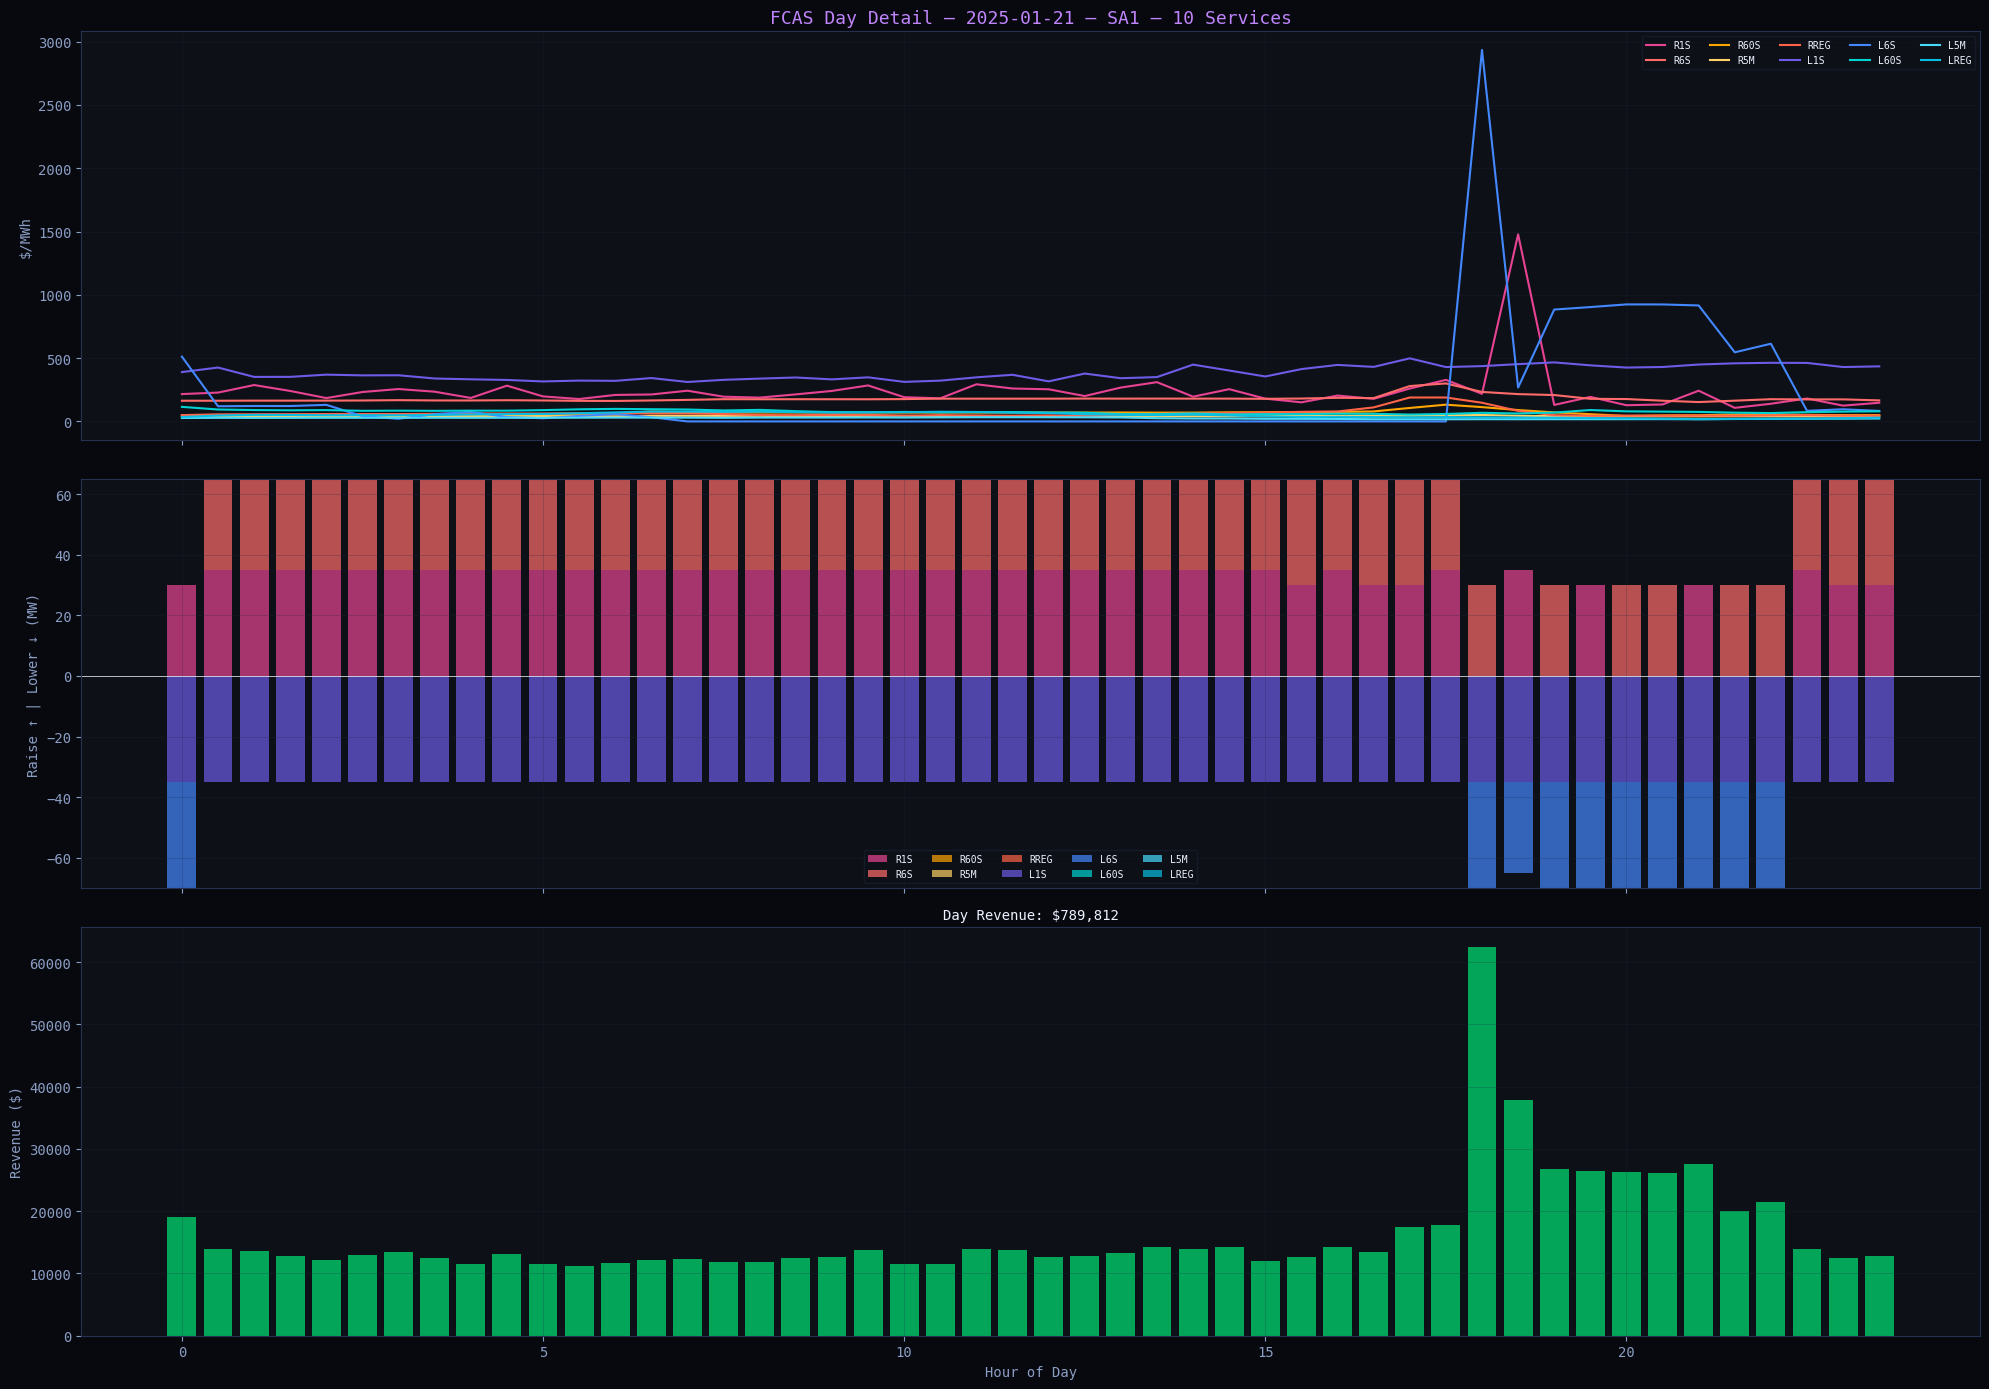


  BID BANDS @ 2025-01-21 12:00:00:
    R1S (MaxAvail=35.0 MW):
      BP 1: $    0.00 ×   7.00 MW
      BP 2: $    2.30 ×   5.25 MW
      BP 3: $    3.82 ×   5.25 MW
      BP 4: $    6.48 ×   3.50 MW
      BP 5: $  253.98 ×   2.80 MW
      BP 6: $  253.99 ×   2.80 MW
      BP 7: $  254.00 ×   2.45 MW
      BP 8: $  254.01 ×   2.45 MW
      BP 9: $  254.02 ×   1.75 MW
      BP10: $  268.88 ×   1.75 MW
    R6S (MaxAvail=30.0 MW):
      BP 1: $    0.00 ×   6.00 MW
      BP 2: $    0.18 ×   4.50 MW
      BP 3: $    0.38 ×   4.50 MW
      BP 4: $    0.39 ×   3.00 MW
      BP 5: $  179.67 ×   2.40 MW
      BP 6: $  179.68 ×   2.40 MW
      BP 7: $  179.69 ×   2.10 MW
      BP 8: $  179.70 ×   2.10 MW
      BP 9: $  179.71 ×   1.50 MW
      BP10: $  179.72 ×   1.50 MW


KeyError: 'MaxAvail'

In [37]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  DAY DETAIL: Show all 10 services + bid bands for a single day  ║
# ╚══════════════════════════════════════════════════════════════════╝

def plot_day_detail(date_str=None):
    if date_str is None:
        daily_rev = revenue['total'].resample('D').sum()
        date_str = str(daily_rev.idxmax().date())
    td = pd.Timestamp(date_str).date()
    mask = pd.Series(df_forecast.index.date == td, index=df_forecast.index)
    d_fc = df_forecast[mask]
    if len(d_fc)==0:
        avail = sorted(set(df_forecast.index.date))
        print(f'  ⚠ No data for {td}. Available: {avail[0]} → {avail[-1]}')
        return
    
    fig, axes = plt.subplots(3, 1, figsize=(20, 14), sharex=True)
    hours = d_fc.index.hour + d_fc.index.minute/60.0
    
    # P1: FCAS prices (all 10)
    for svc in ACTIVE_SERVICES:
        axes[0].plot(hours, d_fc[svc], color=FCAS_META[svc]['color'],
                     label=FCAS_META[svc]['short'], lw=1.5)
    axes[0].set_ylabel('$/MWh')
    axes[0].set_title(f'FCAS Day Detail — {td} — {NEM_REGION} — 10 Services', color='#c084fc', fontsize=13)
    axes[0].legend(ncol=5, fontsize=7); axes[0].grid(True, alpha=0.3)
    
    # P2: MaxAvail allocation
    d_ma = max_avail[mask]
    br = np.zeros(len(d_ma)); bl = np.zeros(len(d_ma))
    w = 0.4
    for svc in ACTIVE_SERVICES:
        vals = d_ma[svc].values
        if 'RAISE' in svc:
            axes[1].bar(hours, vals, width=w, bottom=br, color=FCAS_META[svc]['color'], alpha=0.7, label=FCAS_META[svc]['short'])
            br += vals
        else:
            axes[1].bar(hours, -vals, width=w, bottom=-bl, color=FCAS_META[svc]['color'], alpha=0.7, label=FCAS_META[svc]['short'])
            bl += vals
    axes[1].axhline(0, color='white', lw=0.5)
    axes[1].set_ylabel('Raise ↑ | Lower ↓ (MW)'); axes[1].legend(ncol=5, fontsize=7); axes[1].grid(True, alpha=0.3)
    
    # P3: Revenue
    d_rv = revenue[mask]
    axes[2].bar(hours, d_rv['total'].values, width=w, color=C['revenue'], alpha=0.7)
    axes[2].set_ylabel('Revenue ($)'); axes[2].set_xlabel('Hour of Day')
    axes[2].set_title(f'Day Revenue: ${d_rv["total"].sum():,.0f}', fontsize=10)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'images/day_detail_{td}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print bid band sample for noon
    noon_idx = d_fc.index[min(24, len(d_fc)-1)]
    print(f'\n  BID BANDS @ {noon_idx}:')
    for svc in ACTIVE_SERVICES[:3]:  # show first 3 services
        short = FCAS_META[svc]['short']
        ma_val = bid_bands[svc].loc[noon_idx, 'MaxAvail'] if noon_idx in bid_bands[svc].index else 0
        if not np.isnan(ma_val) and ma_val > 0:
            print(f'    {short} (MaxAvail={ma_val:.1f} MW):')
            for b in range(N_BID_BANDS):
                bp = bid_bands[svc].loc[noon_idx, f'BP{b+1}_price']
                bq = bid_bands[svc].loc[noon_idx, f'BP{b+1}_qty']
                if not np.isnan(bp):
                    print(f'      BP{b+1:>2d}: ${bp:>8.2f} × {bq:>6.2f} MW')

plot_day_detail(PLOT_DAY)

---
## Final Report

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  FINAL REPORT                                                    ║
# ╚══════════════════════════════════════════════════════════════════╝

print('  FINAL REPORT — FCAS BIDDING BOT v2')
print('  ' + '=' * 60)
print(f'  Region: {NEM_REGION}  |  Period: {TARGET_YEAR}-{TARGET_MONTH:02d}  |  BESS: {BESS.power_mw:.0f}MW/{BESS.capacity_mwh:.0f}MWh')
print(f'  FCAS services: {len(ACTIVE_SERVICES)}/10 (incl. R1S/L1S Very Fast 1-sec)')
print(f'  Bid format: {N_BID_BANDS} bands (BP1–BP10) per service per interval')
print(f'\n  MODEL PERFORMANCE (Validation):')
print(f'  {"Svc":>4s} {"Cat":>9s} {"Best MAE":>8s} {"R²":>8s} {"vs BL":>7s}')
print(f'  {"─"*40}')
for svc in ACTIVE_SERVICES:
    best_s = min(val_results[svc].values(), key=lambda x: x['mae'])
    imp = (best_baselines[svc]['mae']-best_s['mae'])/best_baselines[svc]['mae']*100
    print(f'  {FCAS_META[svc]["short"]:>4s} {FCAS_META[svc]["category"]:>9s} ${best_s["mae"]:>6.2f} {best_s["r2"]:>7.4f} {imp:>+6.1f}%')

print(f'\n  REVENUE SUMMARY:')
print(f'  Total:      ${total_rev:>12,.0f}')
print(f'  FCAS:       ${fcas_rev:>12,.0f} ({fcas_rev/max(total_rev,1)*100:.1f}%)')
print(f'  Energy:     ${energy_rev:>12,.0f}')
print(f'  Annualised: ${total_rev*12:>12,.0f}/yr')
print(f'  Per MW/yr:  ${total_rev*12/BESS.power_mw:>12,.0f}')
print(f'\n  ✓ Report complete')

---
## 🔄 Quick Re-Forecast

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  QUICK RE-FORECAST (models in memory)                           ║
# ╚══════════════════════════════════════════════════════════════════╝

def quick_forecast(target_year, target_month, plot_date=None, target_week=None):
    """
    Re-run FCAS forecast + bid bands for any month.
    Models stay in memory — only forecast + bid gen re-runs.
    
    Returns dict with: forecast, bid_bands, revenue, soc, max_avail
    
    Examples:
        r = quick_forecast(2025, 3)
        r = quick_forecast(2025, 6, target_week=2)
        r = quick_forecast(2025, 1, plot_date='2025-01-15')
    """
    print(f'\n  ── QUICK RE-FORECAST: {target_year}-{target_month:02d} ──')
    ts = pd.Timestamp(year=target_year, month=target_month, day=1)
    te = ts + pd.offsets.MonthEnd(1) + pd.Timedelta('23h30min')
    ti = pd.date_range(ts, te, freq='30min')
    if target_week:
        ws = ts + pd.Timedelta(days=(target_week-1)*7)
        we = min(ws + pd.Timedelta(days=7) - pd.Timedelta('30min'), te)
        ti = ti[(ti>=ws)&(ti<=we)]
    
    dfc = pd.DataFrame(index=ti)
    for svc in ACTIVE_SERVICES:
        fc = forecast_svc(svc, df_hist_energy, df_hist_fcas, ti)
        dfc[svc] = fc
        print(f'    {FCAS_META[svc]["short"]}: mean=${fc.mean():.2f}')
    dfc['energy_price'] = _build_anchor(df_hist_energy['price'], ti)
    
    bb, rv, sc, ma = generate_bid_bands(dfc, BESS, ACTIVE_SERVICES)
    print(f'  Total Revenue: ${rv["total"].sum():,.0f}')
    
    # Export
    tag = f'{target_year}{target_month:02d}'
    dfc.to_csv(f'outputs/fcas_forecast_{tag}.csv')
    rv.to_csv(f'outputs/fcas_revenue_{tag}.csv')
    for svc in ACTIVE_SERVICES:
        bb[svc].to_csv(f'outputs/bid_bands_{FCAS_META[svc]["short"]}_{NEM_REGION}_{tag}.csv')
    print(f'  ✓ Saved to outputs/')
    
    if plot_date:
        # Temporarily swap globals for plotting
        globals()['df_forecast'] = dfc
        globals()['revenue'] = rv
        globals()['max_avail'] = ma
        globals()['bid_bands'] = bb
        plot_day_detail(plot_date)
    
    return {'forecast':dfc, 'bid_bands':bb, 'revenue':rv, 'soc':sc, 'max_avail':ma}


print('  ✅  ALL 12 STEPS COMPLETE — 10 FCAS SERVICES + 10 BID BANDS')
print()
print('  ── QUICK RE-FORECAST ────────────────────────────────────')
print('  r = quick_forecast(2025, 3)                    # full month')
print('  r = quick_forecast(2025, 6, target_week=2)     # specific week')
print('  r = quick_forecast(2025, 1, plot_date="2025-01-15")')
print()
print('  ── DAY DETAIL + BID BANDS ───────────────────────────────')
print('  plot_day_detail("2025-01-15")')
print()
print('  ── OUTPUT FILES ─────────────────────────────────────────')
print('  outputs/bid_bands_R1S_SA1_202501.csv   ← AEMO-format 10 bands')
print('  outputs/bid_bands_ALL_SERVICES.csv     ← all services combined')
print('  outputs/fcas_price_forecast_10svc.csv  ← price forecasts')
print('  outputs/fcas_revenue_10svc.csv         ← revenue breakdown')